# Projet : IA for HumanForYou

## EDA - Exploration des données 

# 1. Introduction

L’entreprise *HumanForYou* fait face à un taux de rotation de 15 %, ce qui ralentit les projets, augmente la charge du service RH et demande plus de temps de formation pour les nouveaux employés. L’objectif du projet est d’identifier les facteurs qui influencent ces départs afin d’aider l’entreprise à réduire l’attrition.

L’EDA permet de comprendre, nettoyer et préparer les données, puis d’analyser les variables susceptibles d’influencer l’attrition. Cette étape aide à repérer les tendances importantes et à préparer la modélisation.  


### Plan du notebook
- Préparation et nettoyage des données  
- Analyse univariée  
- Analyse bivariée et multivariée 
- Choix des features pour nos modeles 
- Synthèse des résultats et préparation au modèle


# 2. Chargement et Audit Initial des Données

Dans cette première étape, nous chargeons les différents fichiers nécessaires à l’analyse afin de comprendre la structure des données disponibles. L’objectif est de vérifier les types de variables, la cohérence des informations et la présence de la clé commune *EmployeeID*, indispensable pour les futures fusions.


Nous disposons de 5 fichiers CSV :
* **Données générales** : Informations profils (`general_data.csv`)
* **Enquêtes** : Avis employés (`employee_survey_data.csv`) et managers (`manager_survey_data.csv`)
* **Badgeuses** : Heures d'arrivée (`in_time.csv`) et de départ (`out_time.csv`)


## 2.1 Chargement des 5 fichiers



In [1]:
import pandas as pd

in_time = pd.read_csv(("Data/in_out_time/in_time.csv"))
out_time = pd.read_csv(("Data/in_out_time/out_time.csv"))
general = pd.read_csv(("Data/general_data.csv"))
manager = pd.read_csv(("Data/manager_survey_data.csv"))
employee = pd.read_csv(("Data/employee_survey_data.csv"))

## 2.2 Audit initial de chaque fichier

In [2]:
in_time.head()


,Unnamed: 0,2015-01-01,2015-01-02,2015-01-05,2015-01-06,2015-01-07,2015-01-08,2015-01-09,2015-01-12,2015-01-13,...,2015-12-18,2015-12-21,2015-12-22,2015-12-23,2015-12-24,2015-12-25,2015-12-28,2015-12-29,2015-12-30,2015-12-31
0,1,NaN,2015-01-02 09:43:45,2015-01-05 10:08:48,2015-01-06 09:54:26,2015-01-07 09:34:31,2015-01-08 09:51:09,2015-01-09 10:09:25,2015-01-12 09:42:53,2015-01-13 10:13:06,...,NaN,2015-12-21 09:55:29,2015-12-22 10:04:06,2015-12-23 10:14:27,2015-12-24 10:11:35,NaN,2015-12-28 10:13:41,2015-12-29 10:03:36,2015-12-30 09:54:12,2015-12-31 10:12:44
1,2,NaN,2015-01-02 10:15:44,2015-01-05 10:21:05,NaN,2015-01-07 09:45:17,2015-01-08 10:09:04,2015-01-09 09:43:26,2015-01-12 10:00:07,2015-01-13 10:43:29,...,2015-12-18 10:37:17,2015-12-21 09:49:02,2015-12-22 10:33:51,2015-12-23 10:12:10,NaN,NaN,2015-12-28 09:31:45,2015-12-29 09:55:49,2015-12-30 10:32:25,2015-12-31 09:27:20
2,3,NaN,2015-01-02 10:17:41,2015-01-05 09:50:50,2015-01-06 10:14:13,2015-01-07 09:47:27,2015-01-08 10:03:40,2015-01-09 10:05:49,2015-01-12 10:03:47,2015-01-13 10:21:26,...,2015-12-18 10:15:14,2015-12-21 10:10:28,2015-12-22 09:44:44,2015-12-23 10:15:54,2015-12-24 10:07:26,NaN,2015-12-28 09:42:05,2015-12-29 09:43:36,2015-12-30 09:34:05,2015-12-31 10:28:39
3,4,NaN,2015-01-02 10:05:06,2015-01-05 09:56:32,2015-01-06 10:11:07,2015-01-07 09:37:30,2015-01-08 10:02:08,2015-01-09 10:08:12,2015-01-12 10:13:42,2015-01-13 09:53:22,...,2015-12-18 10:17:38,2015-12-21 09:58:21,2015-12-22 10:04:25,2015-12-23 10:11:46,2015-12-24 09:43:15,NaN,2015-12-28 09:52:44,2015-12-29 09:33:16,2015-12-30 10:18:12,2015-12-31 10:01:15
4,5,NaN,2015-01-02 10:28:17,2015-01-05 09:49:58,2015-01-06 09:45:28,2015-01-07 09:49:37,2015-01-08 10:19:44,2015-01-09 10:00:50,2015-01-12 10:29:27,2015-01-13 09:59:32,...,2015-12-18 09:58:35,2015-12-21 10:03:41,2015-12-22 10:10:30,2015-12-23 10:13:36,2015-12-24 09:44:24,NaN,2015-12-28 10:05:15,2015-12-29 10:30:53,2015-12-30 09:18:21,2015-12-31 09:41:09


In [3]:
out_time.head()

,Unnamed: 0,2015-01-01,2015-01-02,2015-01-05,2015-01-06,2015-01-07,2015-01-08,2015-01-09,2015-01-12,2015-01-13,...,2015-12-18,2015-12-21,2015-12-22,2015-12-23,2015-12-24,2015-12-25,2015-12-28,2015-12-29,2015-12-30,2015-12-31
0,1,NaN,2015-01-02 16:56:15,2015-01-05 17:20:11,2015-01-06 17:19:05,2015-01-07 16:34:55,2015-01-08 17:08:32,2015-01-09 17:38:29,2015-01-12 16:58:39,2015-01-13 18:02:58,...,NaN,2015-12-21 17:15:50,2015-12-22 17:27:51,2015-12-23 16:44:44,2015-12-24 17:47:22,NaN,2015-12-28 18:00:07,2015-12-29 17:22:30,2015-12-30 17:40:56,2015-12-31 17:17:33
1,2,NaN,2015-01-02 18:22:17,2015-01-05 17:48:22,NaN,2015-01-07 17:09:06,2015-01-08 17:34:04,2015-01-09 16:52:29,2015-01-12 17:36:48,2015-01-13 18:00:13,...,2015-12-18 18:31:28,2015-12-21 17:34:16,2015-12-22 18:16:35,2015-12-23 17:38:18,NaN,NaN,2015-12-28 17:08:38,2015-12-29 17:54:46,2015-12-30 18:31:35,2015-12-31 17:40:58
2,3,NaN,2015-01-02 16:59:14,2015-01-05 17:06:46,2015-01-06 16:38:32,2015-01-07 16:33:21,2015-01-08 17:24:22,2015-01-09 16:57:30,2015-01-12 17:28:54,2015-01-13 17:21:25,...,2015-12-18 17:02:23,2015-12-21 17:20:17,2015-12-22 16:32:50,2015-12-23 16:59:43,2015-12-24 16:58:25,NaN,2015-12-28 16:43:31,2015-12-29 17:09:56,2015-12-30 17:06:25,2015-12-31 17:15:50
3,4,NaN,2015-01-02 17:25:24,2015-01-05 17:14:03,2015-01-06 17:07:42,2015-01-07 16:32:40,2015-01-08 16:53:11,2015-01-09 17:19:47,2015-01-12 17:13:37,2015-01-13 17:11:45,...,2015-12-18 17:55:23,2015-12-21 16:49:09,2015-12-22 17:24:00,2015-12-23 17:36:35,2015-12-24 16:48:21,NaN,2015-12-28 17:19:34,2015-12-29 16:58:16,2015-12-30 17:40:11,2015-12-31 17:09:14
4,5,NaN,2015-01-02 18:31:37,2015-01-05 17:49:15,2015-01-06 17:26:25,2015-01-07 17:37:59,2015-01-08 17:59:28,2015-01-09 17:44:08,2015-01-12 18:51:21,2015-01-13 18:14:58,...,2015-12-18 17:52:48,2015-12-21 17:43:35,2015-12-22 18:07:57,2015-12-23 18:00:49,2015-12-24 17:59:22,NaN,2015-12-28 17:44:59,2015-12-29 18:47:00,2015-12-30 17:15:33,2015-12-31 17:42:14


In [4]:
general.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,...,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,1,Female,...,1.0,Y,11,8,0,1.0,6,1,0,0
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,2,Female,...,0.0,Y,23,8,1,6.0,3,5,1,4
2,32,No,Travel_Frequently,Research & Development,17,4,Other,1,3,Male,...,1.0,Y,15,8,3,5.0,2,5,0,3
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,1,4,Male,...,3.0,Y,11,8,3,13.0,5,8,7,5
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,5,Male,...,4.0,Y,12,8,2,9.0,2,6,0,4


In [5]:
manager.head()

,EmployeeID,JobInvolvement,PerformanceRating
0,1,3,3
1,2,2,4
2,3,3,3
3,4,2,3
4,5,3,3


In [6]:
employee.head()

,EmployeeID,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance
0,1,3.0,4.0,2.0
1,2,3.0,2.0,4.0
2,3,2.0,2.0,1.0
3,4,4.0,4.0,3.0
4,5,4.0,1.0,3.0


# 3. Nettoyage et Préparation des Données


## 3.1 Nettoyage initial


Les fichiers horaires ne possèdent pas de nom de colonne pour l'identifiant. Nous allons renommer la colonne `Unnamed: 0` en `EmployeeID` pour assurer la jointure future.

In [7]:
#On renomme la colonne
in_time.rename(columns={"Unnamed: 0": "EmployeeID"}, inplace=True)
out_time.rename(columns={"Unnamed: 0": "EmployeeID"}, inplace=True)

in_time["EmployeeID"] = in_time["EmployeeID"].astype(int)
out_time["EmployeeID"] = out_time["EmployeeID"].astype(int)


In [8]:
in_time.head()


,EmployeeID,2015-01-01,2015-01-02,2015-01-05,2015-01-06,2015-01-07,2015-01-08,2015-01-09,2015-01-12,2015-01-13,...,2015-12-18,2015-12-21,2015-12-22,2015-12-23,2015-12-24,2015-12-25,2015-12-28,2015-12-29,2015-12-30,2015-12-31
0,1,NaN,2015-01-02 09:43:45,2015-01-05 10:08:48,2015-01-06 09:54:26,2015-01-07 09:34:31,2015-01-08 09:51:09,2015-01-09 10:09:25,2015-01-12 09:42:53,2015-01-13 10:13:06,...,NaN,2015-12-21 09:55:29,2015-12-22 10:04:06,2015-12-23 10:14:27,2015-12-24 10:11:35,NaN,2015-12-28 10:13:41,2015-12-29 10:03:36,2015-12-30 09:54:12,2015-12-31 10:12:44
1,2,NaN,2015-01-02 10:15:44,2015-01-05 10:21:05,NaN,2015-01-07 09:45:17,2015-01-08 10:09:04,2015-01-09 09:43:26,2015-01-12 10:00:07,2015-01-13 10:43:29,...,2015-12-18 10:37:17,2015-12-21 09:49:02,2015-12-22 10:33:51,2015-12-23 10:12:10,NaN,NaN,2015-12-28 09:31:45,2015-12-29 09:55:49,2015-12-30 10:32:25,2015-12-31 09:27:20
2,3,NaN,2015-01-02 10:17:41,2015-01-05 09:50:50,2015-01-06 10:14:13,2015-01-07 09:47:27,2015-01-08 10:03:40,2015-01-09 10:05:49,2015-01-12 10:03:47,2015-01-13 10:21:26,...,2015-12-18 10:15:14,2015-12-21 10:10:28,2015-12-22 09:44:44,2015-12-23 10:15:54,2015-12-24 10:07:26,NaN,2015-12-28 09:42:05,2015-12-29 09:43:36,2015-12-30 09:34:05,2015-12-31 10:28:39
3,4,NaN,2015-01-02 10:05:06,2015-01-05 09:56:32,2015-01-06 10:11:07,2015-01-07 09:37:30,2015-01-08 10:02:08,2015-01-09 10:08:12,2015-01-12 10:13:42,2015-01-13 09:53:22,...,2015-12-18 10:17:38,2015-12-21 09:58:21,2015-12-22 10:04:25,2015-12-23 10:11:46,2015-12-24 09:43:15,NaN,2015-12-28 09:52:44,2015-12-29 09:33:16,2015-12-30 10:18:12,2015-12-31 10:01:15
4,5,NaN,2015-01-02 10:28:17,2015-01-05 09:49:58,2015-01-06 09:45:28,2015-01-07 09:49:37,2015-01-08 10:19:44,2015-01-09 10:00:50,2015-01-12 10:29:27,2015-01-13 09:59:32,...,2015-12-18 09:58:35,2015-12-21 10:03:41,2015-12-22 10:10:30,2015-12-23 10:13:36,2015-12-24 09:44:24,NaN,2015-12-28 10:05:15,2015-12-29 10:30:53,2015-12-30 09:18:21,2015-12-31 09:41:09


In [9]:
out_time.head()


,EmployeeID,2015-01-01,2015-01-02,2015-01-05,2015-01-06,2015-01-07,2015-01-08,2015-01-09,2015-01-12,2015-01-13,...,2015-12-18,2015-12-21,2015-12-22,2015-12-23,2015-12-24,2015-12-25,2015-12-28,2015-12-29,2015-12-30,2015-12-31
0,1,NaN,2015-01-02 16:56:15,2015-01-05 17:20:11,2015-01-06 17:19:05,2015-01-07 16:34:55,2015-01-08 17:08:32,2015-01-09 17:38:29,2015-01-12 16:58:39,2015-01-13 18:02:58,...,NaN,2015-12-21 17:15:50,2015-12-22 17:27:51,2015-12-23 16:44:44,2015-12-24 17:47:22,NaN,2015-12-28 18:00:07,2015-12-29 17:22:30,2015-12-30 17:40:56,2015-12-31 17:17:33
1,2,NaN,2015-01-02 18:22:17,2015-01-05 17:48:22,NaN,2015-01-07 17:09:06,2015-01-08 17:34:04,2015-01-09 16:52:29,2015-01-12 17:36:48,2015-01-13 18:00:13,...,2015-12-18 18:31:28,2015-12-21 17:34:16,2015-12-22 18:16:35,2015-12-23 17:38:18,NaN,NaN,2015-12-28 17:08:38,2015-12-29 17:54:46,2015-12-30 18:31:35,2015-12-31 17:40:58
2,3,NaN,2015-01-02 16:59:14,2015-01-05 17:06:46,2015-01-06 16:38:32,2015-01-07 16:33:21,2015-01-08 17:24:22,2015-01-09 16:57:30,2015-01-12 17:28:54,2015-01-13 17:21:25,...,2015-12-18 17:02:23,2015-12-21 17:20:17,2015-12-22 16:32:50,2015-12-23 16:59:43,2015-12-24 16:58:25,NaN,2015-12-28 16:43:31,2015-12-29 17:09:56,2015-12-30 17:06:25,2015-12-31 17:15:50
3,4,NaN,2015-01-02 17:25:24,2015-01-05 17:14:03,2015-01-06 17:07:42,2015-01-07 16:32:40,2015-01-08 16:53:11,2015-01-09 17:19:47,2015-01-12 17:13:37,2015-01-13 17:11:45,...,2015-12-18 17:55:23,2015-12-21 16:49:09,2015-12-22 17:24:00,2015-12-23 17:36:35,2015-12-24 16:48:21,NaN,2015-12-28 17:19:34,2015-12-29 16:58:16,2015-12-30 17:40:11,2015-12-31 17:09:14
4,5,NaN,2015-01-02 18:31:37,2015-01-05 17:49:15,2015-01-06 17:26:25,2015-01-07 17:37:59,2015-01-08 17:59:28,2015-01-09 17:44:08,2015-01-12 18:51:21,2015-01-13 18:14:58,...,2015-12-18 17:52:48,2015-12-21 17:43:35,2015-12-22 18:07:57,2015-12-23 18:00:49,2015-12-24 17:59:22,NaN,2015-12-28 17:44:59,2015-12-29 18:47:00,2015-12-30 17:15:33,2015-12-31 17:42:14


### C. Audit des types de données et valeurs manquantes
Vérification des types de variables (int, object, float) et détection des valeurs nulles potentielles.

In [10]:
general.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   int64  
 1   Attrition                4410 non-null   object 
 2   BusinessTravel           4410 non-null   object 
 3   Department               4410 non-null   object 
 4   DistanceFromHome         4410 non-null   int64  
 5   Education                4410 non-null   int64  
 6   EducationField           4410 non-null   object 
 7   EmployeeCount            4410 non-null   int64  
 8   EmployeeID               4410 non-null   int64  
 9   Gender                   4410 non-null   object 
 10  JobLevel                 4410 non-null   int64  
 11  JobRole                  4410 non-null   object 
 12  MaritalStatus            4410 non-null   object 
 13  MonthlyIncome            4410 non-null   int64  
 14  NumCompaniesWorked      

In [11]:
employee.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   EmployeeID               4410 non-null   int64  
 1   EnvironmentSatisfaction  4385 non-null   float64
 2   JobSatisfaction          4390 non-null   float64
 3   WorkLifeBalance          4372 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 137.9 KB


In [12]:
manager.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   EmployeeID         4410 non-null   int64
 1   JobInvolvement     4410 non-null   int64
 2   PerformanceRating  4410 non-null   int64
dtypes: int64(3)
memory usage: 103.5 KB


In [13]:
in_time.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Columns: 262 entries, EmployeeID to 2015-12-31
dtypes: float64(12), int64(1), object(249)
memory usage: 8.8+ MB


In [14]:
out_time.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Columns: 262 entries, EmployeeID to 2015-12-31
dtypes: float64(12), int64(1), object(249)
memory usage: 8.8+ MB


### Analyse des jeux de données

#### in_time / out_time
Les fichiers horaires contiennent principalement des dates sous forme de texte (object), ce qui est attendu.
Il sera ainsi necessaire de les parser en type date par la suite.
#### employee
- Les types de données sont corrects.
- Quelques valeurs manquantes sont présentes dans des colonnes de type *float*.

#### manager
- Données propres.
- Toutes les colonnes sont de type **int**.

#### general
- Structure cohérente.
- Deux colonnes sont en type *float* à cause de valeurs manquantes :
  - `NumCompaniesWorked`
  - `TotalWorkingYears`
- Un nettoyage sera nécessaire pour ces deux colonnes.


## 3.2 Détection et traitement des doublons

In [15]:
employee['EmployeeID'].duplicated().sum()

np.int64(0)

In [16]:
manager['EmployeeID'].duplicated().sum()

np.int64(0)

In [17]:
general['EmployeeID'].duplicated().sum()

np.int64(0)

In [18]:
in_time['EmployeeID'].duplicated().sum()

np.int64(0)

In [19]:
out_time['EmployeeID'].duplicated().sum()

np.int64(0)

### Vérifier la presence de la colonne EmployeeID

In [20]:
employee.columns

Index(['EmployeeID', 'EnvironmentSatisfaction', 'JobSatisfaction',
       'WorkLifeBalance'],
      dtype='object')

In [21]:
manager.columns

Index(['EmployeeID', 'JobInvolvement', 'PerformanceRating'], dtype='object')

In [22]:
general.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome',
       'Education', 'EducationField', 'EmployeeCount', 'EmployeeID', 'Gender',
       'JobLevel', 'JobRole', 'MaritalStatus', 'MonthlyIncome',
       'NumCompaniesWorked', 'Over18', 'PercentSalaryHike', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [23]:
in_time.columns

Index(['EmployeeID', '2015-01-01', '2015-01-02', '2015-01-05', '2015-01-06',
       '2015-01-07', '2015-01-08', '2015-01-09', '2015-01-12', '2015-01-13',
       ...
       '2015-12-18', '2015-12-21', '2015-12-22', '2015-12-23', '2015-12-24',
       '2015-12-25', '2015-12-28', '2015-12-29', '2015-12-30', '2015-12-31'],
      dtype='object', length=262)

In [24]:
out_time.columns

Index(['EmployeeID', '2015-01-01', '2015-01-02', '2015-01-05', '2015-01-06',
       '2015-01-07', '2015-01-08', '2015-01-09', '2015-01-12', '2015-01-13',
       ...
       '2015-12-18', '2015-12-21', '2015-12-22', '2015-12-23', '2015-12-24',
       '2015-12-25', '2015-12-28', '2015-12-29', '2015-12-30', '2015-12-31'],
      dtype='object', length=262)

### D. Vérification de la clé primaire (EmployeeID)

Nous assurons que chaque employé est unique et que la clé `EmployeeID` est présente et cohérente dans tous les fichiers (4410 employés attendus).

In [25]:
print(len(employee), len(manager), len(general), len(in_time), len(out_time))

4410 4410 4410 4410 4410


## Feature Engineering : Analyse des Temps de Travail

Les données brutes des badgeuses (`in_time` et `out_time`) ne sont pas exploitables directement. Nous allons créer des indicateurs de performance et de bien-être au travail.

**Indicateurs créés :**
* Temps de travail quotidien moyen.
* Heures supplémentaires.
* Taux de retard ou de départ anticipé.
* Identification des jours fériés/absences.
* Et autres features d'horaires relatifs a chaque employe. La liste exhaustive est presentee plus bas avec leur interet




on va utiliser les fichiers in_time et out_time pour creer un nouveau tableau df_time pour avoir un indicateur de temps 

In [26]:
#Mettre EmployeeID en index
in_time.set_index("EmployeeID", inplace=True)
out_time.set_index("EmployeeID", inplace=True)

# Convertir en format datetime
in_time = in_time.apply(pd.to_datetime, errors="coerce")
out_time = out_time.apply(pd.to_datetime, errors="coerce")

# La soustraction
raw_work_time = out_time - in_time


In [27]:
raw_work_time.head()


,2015-01-01,2015-01-02,2015-01-05,2015-01-06,2015-01-07,2015-01-08,2015-01-09,2015-01-12,2015-01-13,2015-01-14,...,2015-12-18,2015-12-21,2015-12-22,2015-12-23,2015-12-24,2015-12-25,2015-12-28,2015-12-29,2015-12-30,2015-12-31
EmployeeID,,,,,,,,,,,,,,,,,,,,,
1,NaT,0 days 07:12:30,0 days 07:11:23,0 days 07:24:39,0 days 07:00:24,0 days 07:17:23,0 days 07:29:04,0 days 07:15:46,0 days 07:49:52,NaT,...,NaT,0 days 07:20:21,0 days 07:23:45,0 days 06:30:17,0 days 07:35:47,NaT,0 days 07:46:26,0 days 07:18:54,0 days 07:46:44,0 days 07:04:49
2,NaT,0 days 08:06:33,0 days 07:27:17,NaT,0 days 07:23:49,0 days 07:25:00,0 days 07:09:03,0 days 07:36:41,0 days 07:16:44,NaT,...,0 days 07:54:11,0 days 07:45:14,0 days 07:42:44,0 days 07:26:08,NaT,NaT,0 days 07:36:53,0 days 07:58:57,0 days 07:59:10,0 days 08:13:38
3,NaT,0 days 06:41:33,0 days 07:15:56,0 days 06:24:19,0 days 06:45:54,0 days 07:20:42,0 days 06:51:41,0 days 07:25:07,0 days 06:59:59,NaT,...,0 days 06:47:09,0 days 07:09:49,0 days 06:48:06,0 days 06:43:49,0 days 06:50:59,NaT,0 days 07:01:26,0 days 07:26:20,0 days 07:32:20,0 days 06:47:11
4,NaT,0 days 07:20:18,0 days 07:17:31,0 days 06:56:35,0 days 06:55:10,0 days 06:51:03,0 days 07:11:35,0 days 06:59:55,0 days 07:18:23,NaT,...,0 days 07:37:45,0 days 06:50:48,0 days 07:19:35,0 days 07:24:49,0 days 07:05:06,NaT,0 days 07:26:50,0 days 07:25:00,0 days 07:21:59,0 days 07:07:59
5,NaT,0 days 08:03:20,0 days 07:59:17,0 days 07:40:57,0 days 07:48:22,0 days 07:39:44,0 days 07:43:18,0 days 08:21:54,0 days 08:15:26,NaT,...,0 days 07:54:13,0 days 07:39:54,0 days 07:57:27,0 days 07:47:13,0 days 08:14:58,NaT,0 days 07:39:44,0 days 08:16:07,0 days 07:57:12,0 days 08:01:05


In [28]:
#Transformer en heures + moyenne 
work_hours = raw_work_time.apply(lambda col: col.dt.total_seconds() / 3600)



In [29]:
import warnings
warnings.filterwarnings("ignore")

#### Conversion des donnees de in_time et out_time en format Date

In [30]:
# Conversion en format Date (datetime)
# errors='coerce' transforme les valeurs non-lises en NaT (Not a Time)
in_time = in_time.apply(pd.to_datetime, errors='coerce')
out_time = out_time.apply(pd.to_datetime, errors='coerce')

### Gestion des jours fériés et non travaillés
Nous identifions les jours où la majorité des employés sont absents (Fériés) pour ne pas fausser les moyennes de temps de travail.
On considere naivement que si moins de 5% des employes sont presents un jour, alors on dira que ce jour est ferie.

In [31]:
# On calcule le taux de présence moyen pour chaque jour (colonne)
presence_rate = ((in_time.notna().sum() + out_time.notna().sum()) / 2) / len(in_time)

# Seuil de 5% : si moins de 5% des gens sont là, c'est un jour férié ou un week-end
presence_threshold = 0.05
holidays = presence_rate[presence_rate < presence_threshold].index

print(f"{len(holidays)} jours identifiés comme non travaillés (Fériés/WE).")

# On retire ces jours des calculs pour ne pas fausser les moyennes
# (On remplace les valeurs de ces colonnes par NaT)
in_clean = in_time.copy()
out_clean = out_time.copy()
in_clean.loc[:, holidays] = pd.NaT
out_clean.loc[:, holidays] = pd.NaT




12 jours identifiés comme non travaillés (Fériés/WE).


### Création des variables temporelles avancées
Calcul des statistiques descriptives sur les horaires (Moyenne, Médiane, Retards, Heures Supp.).

In [ ]:
# Différence Out - In convertie en heures
hours_worked = (out_clean - in_clean) / pd.Timedelta(hours=1)
# On borne entre 0 et 24h pour éviter les incohérences
hours_worked = hours_worked.clip(lower=0, upper=24)

 # Masque des jours travaillés (exclut weekends/fériés)
valid_cols = ~in_time.columns.isin(holidays) # On exclut les jours feries
in_valid = in_time.loc[:, valid_cols] # donnees des badgeuses les jours ouvres
out_valid = out_time.loc[:, valid_cols] # donnees des badgeuses les jours ouvres

# Création du DataFrame des nouvelles features
time_features = pd.DataFrame(index=hours_worked.index)

# Statistiques de base
time_features['Total_Working_Days'] = hours_worked.notna().sum(axis=1)
time_features['Avg_Daily_Hours'] = hours_worked.mean(axis=1)
time_features['Median_Daily_Hours'] = hours_worked.median(axis=1) # Plus robuste aux valeurs extrêmes
time_features['Std_Daily_Hours'] = hours_worked.std(axis=1)       # Régularité des horaires

# Heures Supplémentaires ---
# Fonction pour créer des quartiles pour les nombres de temps (Jours) de travail cumule sur toute l'annee
def safe_qcut(series, q=4, labels=None):
    if labels is None:
        labels = [f'Q{i+1}' for i in range(q)]
    try:
        return pd.qcut(series, q=q, labels=labels, duplicates='drop')
    except:
        max_val = series.max()
        bins = [-1, 0, 5, 20, max_val + 1]
        return pd.cut(series, bins=bins, labels=labels, include_lowest=True)
    
# Compte le nombre de jours où l'employé a travaillé plus de 8.5h ou 10h
time_features['Overtime_Days_8.5h'] = (hours_worked > 8.5).sum(axis=1)
time_features['Overtime_Days_10h'] = (hours_worked > 10).sum(axis=1)

# Retards et Absences
# Arrivées tardives (après 10h30) sur les jours ouvrés uniquement
valid_cols = ~in_time.columns.isin(holidays)
in_valid = in_time.loc[:, valid_cols]

# On regarde l'heure (hour) + les minutes converties (minute/60)
time_features['Late_Arrival_Rate'] = (in_valid.apply(lambda col: (col.dt.hour + col.dt.minute/60) > 10.5)).mean(axis=1)

# Taux d'absence (Jours manqués / Jours ouvrés théoriques)
expected_days = len(hours_worked.columns) - len(holidays)
time_features['Absence_Rate'] = hours_worked.isna().sum(axis=1) / expected_days

# Taux d'arrivée très tôt (<7h30), tard (>10h30), départ tôt (<16h30)
time_features['Very_Early_Start_Rate'] = (in_valid.apply(lambda col: (col.dt.hour + col.dt.minute/60) < 7.5)).mean(axis=1) # on applique une fonction anonyme a chaque colonne afin de la convertir en heure flottante
time_features['Late_Arrival_Rate'] = (in_valid.apply(lambda col: (col.dt.hour + col.dt.minute/60) > 10.5)).mean(axis=1)
time_features['Early_Leave_Rate'] = (out_valid.apply(lambda col: (col.dt.hour + col.dt.minute/60) < 16.5)).mean(axis=1)

# Présentéisme stratégique : vendredi soir (>18h) et lundi matin (<9h30)
friday_out = out_time.apply(lambda col: (col.dt.dayofweek == 4) & (col.dt.hour >= 18)).mean(axis=1)
monday_in = in_time.apply(lambda col: (col.dt.dayofweek == 0) & ((col.dt.hour < 9) | ((col.dt.hour == 9) & (col.dt.minute < 30)))).mean(axis=1)
time_features['Friday_Evening_Presence_Rate'] = friday_out
time_features['Monday_Morning_Presence_Rate'] = monday_in



# Features Horaires Développées : Nécessité, Intérêt Business et Formules Mathématiques

## Introduction

Ces *features*, créées à partir des données badgeuses ($in\_time$ et $out\_time$), transforment des horodatages bruts en **indicateurs comportementaux concrets**.
Elles sont essentielles car elles capturent des signaux de **burnout**, de **désengagement** et de déséquilibre **vie professionnelle/personnelle**, invisibles dans les variables statiques (salaire, satisfaction déclarative).
Dans notre analyse exploratoire (EDA), plusieurs d'entre elles (notamment `Overtime_Days_10h`) se sont révélées **parmi les plus prédictives** du *turnover*.

---

## Tableau Synthétique des *Features*

| Feature | Nécessité & Intérêt Business | Formule Mathématique |
| :--- | :--- | :--- |
| **Total_Working_Days** | Mesure la présence effective sur l'année (hors weekends/fériés). Utile pour détecter les absences répétées précoces. | $Total_Working_Days = \sum_{d} \mathbb{1}(entrée_d \neq NaT \ \lor \ sortie_d \neq NaT)$ |
| **Avg_Daily_Hours** | Charge quotidienne moyenne. Indicateur direct de surcharge structurelle (burnout). | $Avg_Daily_Hours = \frac{1}{N_{jours}} \times \sum_{d} (sortie_d - entrée_d)$ |
| **Median_Daily_Hours** | Charge « typique » (robuste aux *outliers*). Complète la moyenne. | $Median_Daily_Hours = \text{médiane}(sortie_d - entrée_d)$ |
| **Std_Daily_Hours** | Variabilité des horaires. Horaires irréguliers = stress supplémentaire. | $Std_Daily_Hours = \sqrt{ \frac{1}{N} \times \sum_{d} (heures_d - \mu)^2 }$ où $\mu = Avg\_Daily\_Hours$ |
| **Overtime_Days_10h** | Nombre de journées > 10h. **Feature la plus prédictive** : risque multiplié par 4-5 en Q4. | $Overtime_Days_10h = \sum_{d} \mathbb{1}((sortie_d - entrée_d) > 10)$ |
| **Overtime_Days_8.5h** | Variante sensible (> 8.5h contrat standard). Détecte la surcharge modérée. | $Overtime_Days_8.5h = \sum_{d} \mathbb{1}((sortie_d - entrée_d) > 8.5)$ |
| **Absence_Rate** | Taux d'absence non justifiée. Signe précoce de désengagement. | $Absence_Rate = \frac{\text{Jours manquants}}{\text{Jours ouvrés attendus}}$ |
| **Very_Early_Start_Rate** | % de jours avec arrivée < 7h30. Indique des contraintes personnelles ou une pression forte. |$Very_Early_Start_Rate = \frac{1}{N} \times \sum_{d} \mathbb{1}(entrée_d < 7.5)$ |
| **Late_Arrival_Rate** | % de jours avec arrivée > 10h30. Peut indiquer flexibilité ou démotivation. | $Late_Arrival_Rate = \frac{1}{N} \times \sum_{d} \mathbb{1}(entrée_d > 10.5)$ |
| **Early_Leave_Rate** | % de jours avec départ < 16h30. Témoigne de l'équilibre vie pro/perso ou d'un manque d'implication. | $Early_Leave_Rate = \frac{1}{N} \times \sum_{d} \mathbb{1}(sortie_d < 16.5)$ |
| **Friday_Evening_Presence_Rate** | % des vendredis avec départ ≥ 18h. Culture d'engagement – **protecteur** (risque $\downarrow$). | $Friday_Evening_Presence_Rate = \frac{1}{N_{vendredis}} \times \sum_{vendredi} \mathbb{1}(sortie_{vendredi} \geq 18)$ |
| **Monday_Morning_Presence_Rate** | % des lundis avec arrivée < 9h30. Indicateur de motivation en début de semaine. |$`Monday_Morning_Presence_Rate = \frac{1}{N_{lundis}} \times \sum_{lundi} \mathbb{1}(entrée_{lundi} < 9.5$ |
| **Young_Stagnation** | Combinaison âge jeune + stagnation promotionnelle. | $Young_Stagnation = \mathbb{1}((\text{Age} < 35) \ \land \ (\text{YearsSinceLastPromotion} > 3))$ |
| **Attrition_Num** | Conversion de la cible en valeur numérique (0/1) – obligatoire pour la modélisation. | $Attrition_Num = \mathbb{1}(\text{Attrition} = "Yes")$ |

---

## Détails des Formules

### 1. *Features* de Durée
- **Total_Working_Days** : Nombre de jours avec au moins un badgeage (entrée ou sortie).
- **Avg_Daily_Hours** : Moyenne arithmétique des heures travaillées par jour (sur les jours badgés).
- **Median_Daily_Hours** : Médiane pour être robuste aux *outliers*.
- **Std_Daily_Hours** : Écart-type de la durée quotidienne (mesure de l'irrégularité).

### 2. *Features* d'*Overtime*
- **Overtime_Days_10h** : Comptage des jours > 10h (seuil fort de surcharge).
- **Overtime_Days_8.5h** : Comptage des jours > 8.5h (seuil standard).
- **Overtime_Flag** : Variable binaire si le nombre de jours d'*overtime* dépasse un seuil annuel $k$.

### 3. *Features* Comportementales (Taux)
- **Absence_Rate** : Taux d'absence non justifiée.
- **Very_Early_Start_Rate** : Taux d'arrivées avant 7h30.
- **Late_Arrival_Rate** : Taux d'arrivées après 10h30.
- **Early_Leave_Rate** : Taux de départs avant 16h30.
- **Friday_Evening_Presence_Rate** : Taux de présence tardive le vendredi.
- **Monday_Morning_Presence_Rate** : Taux d'arrivée tôt le lundi.

### 4. *Features* Composite
- **Young_Stagnation** : Variable booléenne identifiant les jeunes employés sans promotion récente.
- **Attrition_Num** : Variable cible transformée en numérique (régression/classification).

---

## Variables et Paramètres

| Variable | Description | Format / Unité |
| :--- | :--- | :--- |
| $entrée_d$ | Heure d'entrée du jour $d$ | Heure (float : $7.5 = 7h30$) |
| $sortie_d$ | Heure de sortie du jour $d$ | Heure (float : $16.5 = 16h30$) |
| $NaT$ | Valeur manquante (*Not a Time*) | - |
| $N$ | Nombre total de jours valides dans la période | Entier |
| $\mathbb{1}(condition)$ | **Fonction indicatrice** (de Kronecker) | 1 si la condition est vraie, 0 sinon |
| $\sum_{d}$ | Sommation sur tous les jours $d$ de la période | - |
| $\mu$ | Moyenne (généralement `Avg_Daily_Hours`) | Heures |

## Construction du Dataset Final Nettoyage et fusion


Nous regroupons maintenant toutes les informations (Profils + Enquêtes + Indicateurs Temps calculés) dans un tableau unique `df_merged`.



In [33]:
# Base = general_data
df_merged = general.copy()

# 1) Merge avec les données manager
df_merged = df_merged.merge(manager, on="EmployeeID", how="left")

# 2) Merge avec les données employee
df_merged = df_merged.merge(employee, on="EmployeeID", how="left")

# 3) Merge avec les heures moyennes de travail
df_merged = df_merged.merge(time_features, on="EmployeeID", how="left")

#ajouter l'attrition en nombre

df_merged["Attrition_Num"] = df_merged["Attrition"].map({
    "Yes": 1,
    "No": 0
})

df_merged["Attrition_Num"].dtype

# Le profil "Jeune et Bloqué

df_merged["Young_Stagnation"] = (
    (df_merged["Age"] < 30) &
    (df_merged["YearsSinceLastPromotion"] > 2)
).astype(int)


# Moyenne par employé (par ligne)
avg_work_hours = work_hours.mean(axis=1)

#Construire  DataFrame finaL
df_merged["Avg_Work_Hours"] = avg_work_hours
# Intensité du Travail : On compare les heures réellement travaillées aux 8h contractuelles.

df_merged["Work_Intensity"] = df_merged["Avg_Work_Hours"] / 8


# Flag Heures Sup’ 
df_merged["Overtime_Flag"] = (df_merged["Avg_Work_Hours"] > 8.5).astype(int)

#TEST
# df_merged[["Avg_Work_Hours", "Work_Intensity", "Overtime_Flag"]].head(20)


In [35]:
df_merged.head()


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,...,Absence_Rate,Very_Early_Start_Rate,Early_Leave_Rate,Friday_Evening_Presence_Rate,Monday_Morning_Presence_Rate,Attrition_Num,Young_Stagnation,Avg_Work_Hours,Work_Intensity,Overtime_Flag
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,1,Female,...,0.116466,0.0,0.020080,0.000000,0.011494,0,0,NaN,NaN,0
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,2,Female,...,0.100402,0.0,0.004016,0.042146,0.000000,1,0,7.373651,0.921706,0
2,32,No,Travel_Frequently,Research & Development,17,4,Other,1,3,Male,...,0.076305,0.0,0.100402,0.000000,0.011494,0,0,7.718969,0.964871,0
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,1,4,Male,...,0.104418,0.0,0.040161,0.003831,0.003831,0,0,7.013240,0.876655,0
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,5,Male,...,0.064257,0.0,0.000000,0.084291,0.003831,0,0,7.193678,0.899210,0


## 3.3 Détection et traitement des valeurs manquantes

<Figure size 1200x600 with 0 Axes>

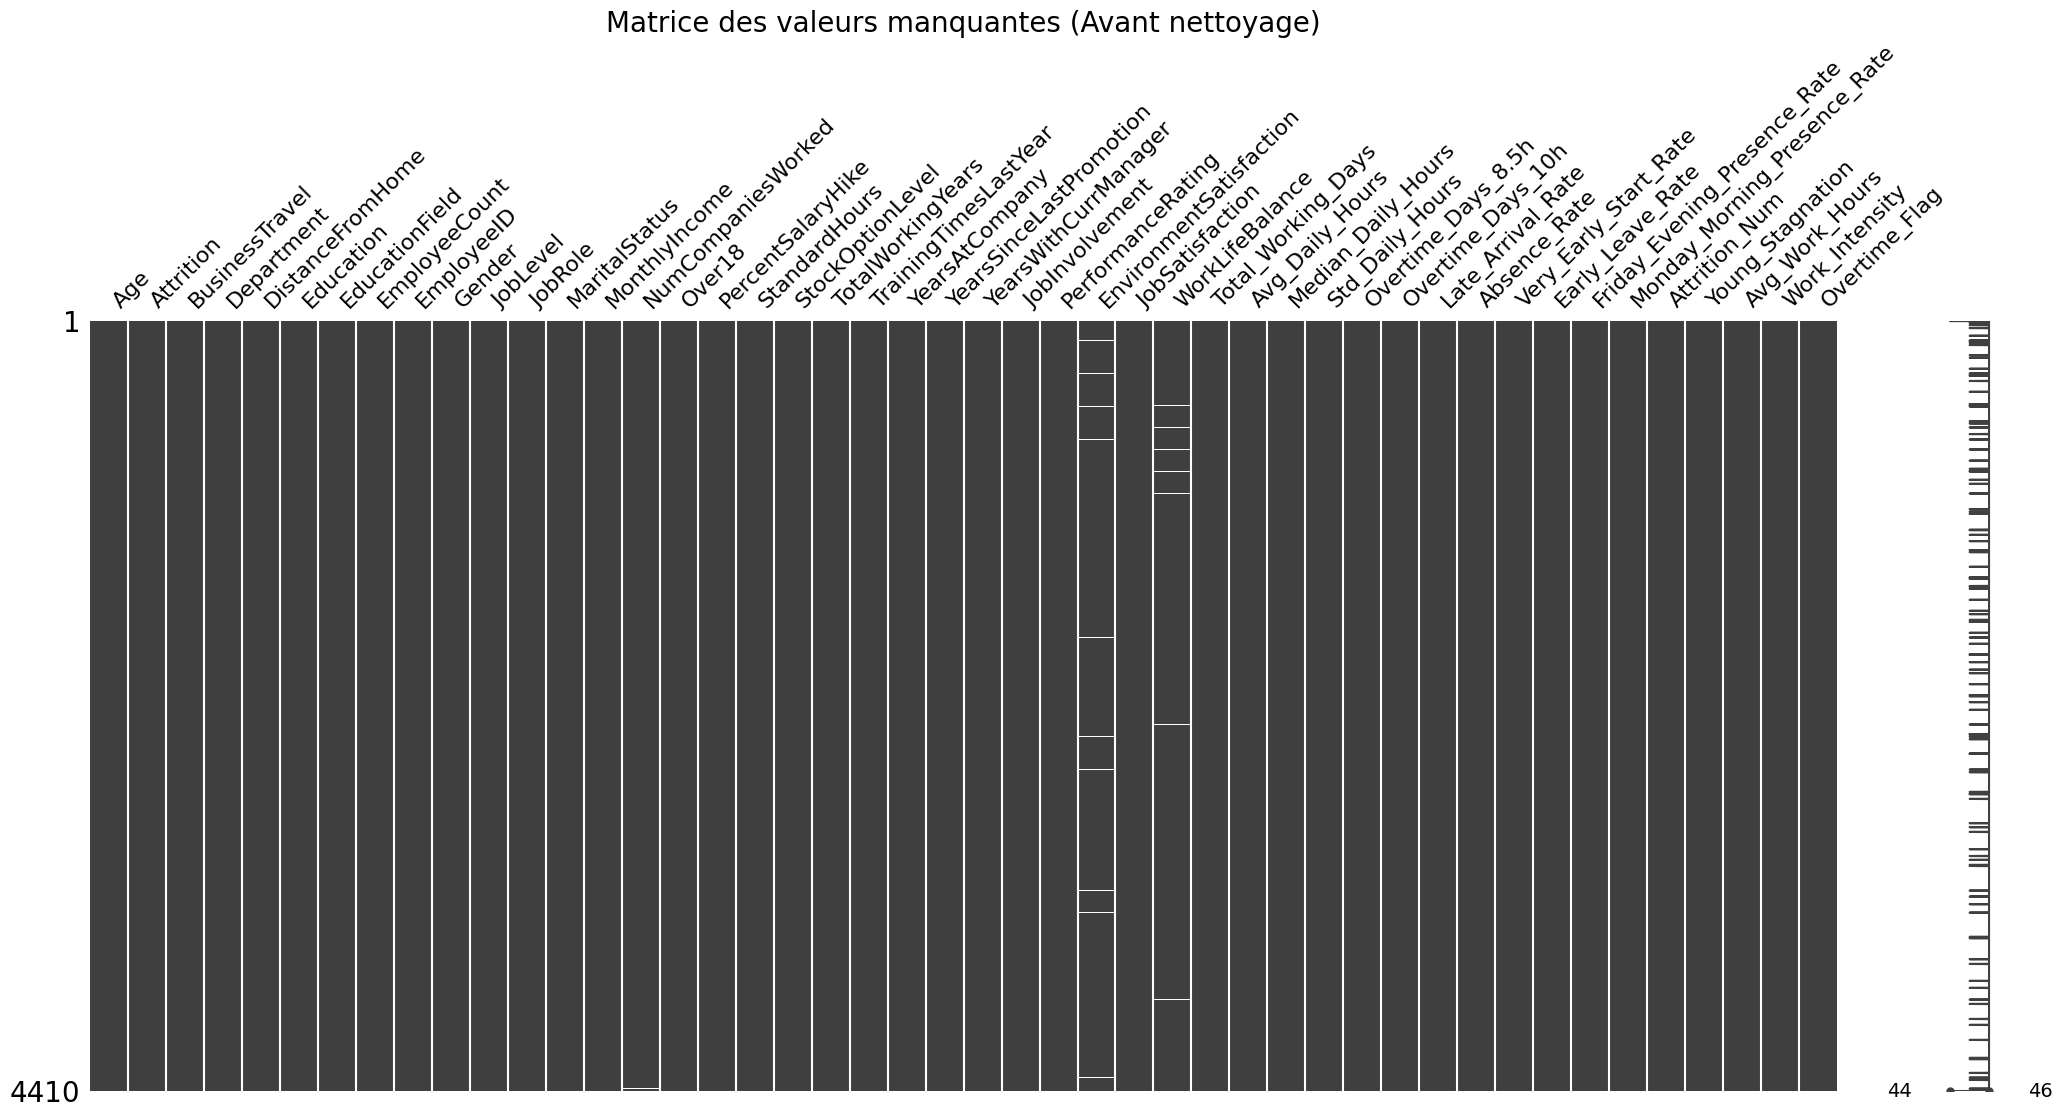

In [36]:


import missingno as msno
import matplotlib.pyplot as plt

#  Visualisation de la matrice des valeurs manquantes sur le dataset fusionné
# Cela permet de voir la distribution des manques et les corrélations entre eux
plt.figure(figsize=(12, 6))
msno.matrix(df_merged)
plt.title("Matrice des valeurs manquantes (Avant nettoyage)", fontsize=20)
plt.show()



### Le nettoyage Final 

Nous allons enlever les colonnes qui ne servent à rien 
Ces colonnes presentes des variances nulles donc tres peu pertinente pour la suite.

In [37]:
#on supprime les bruits, soir les colonnes constantes qui ne sert à rien 
df_merged = df_merged.drop(columns=["StandardHours", "Over18", "EmployeeCount"])



In [38]:
#Gérer les valeurs manquantes


# Variables numériques
#on récup les colonnes  numériques uniquement 
num_cols = df_merged.select_dtypes(include=["int64", "float64"]).columns

#on remplace les valeur NA par la médiane 

df_merged[num_cols] = df_merged[num_cols].fillna(df_merged[num_cols].median())

# Variables catégorielles
# On récupère les colonnes de type 'object' (chaînes de caractères)
cat_cols = df_merged.select_dtypes(include=["object"]).columns

# On remplace les valeurs manquantes par le mode de chaque colonne
for col in cat_cols:
    # mode() renvoie une série, on prend le premier élément [0]
    df_merged[col] = df_merged[col].fillna(df_merged[col].mode()[0])

# Vérification (Optionnel) : S'assurer qu'il ne reste plus de valeurs manquantes
print(df_merged.isnull().sum().sum())

0


In [39]:
import numpy as np
# Sécurisation Technique (anti-crash) EVITER D'avoir infini avec le calcul des features 
df_merged.replace([np.inf, -np.inf], np.nan, inplace=True)

# on remplace INF PAR NAN
df_merged.fillna(df_merged.median(numeric_only=True), inplace=True)


## 3. Analyse Exploratoire (EDA)

add describtion

On va visualiser la distribution de la cible attrition et analusze lzq variables numérique 

### Analyse Univariée 

### Explorer la Cible (Attrition)

In [40]:
#compter le nombre de yes et no avec l'attrition
df_merged["Attrition"].value_counts()


Attrition
No     3699
Yes     711
Name: count, dtype: int64

In [41]:
# Afficher le résultat en %
df_merged["Attrition"].value_counts(normalize=True) * 100


Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

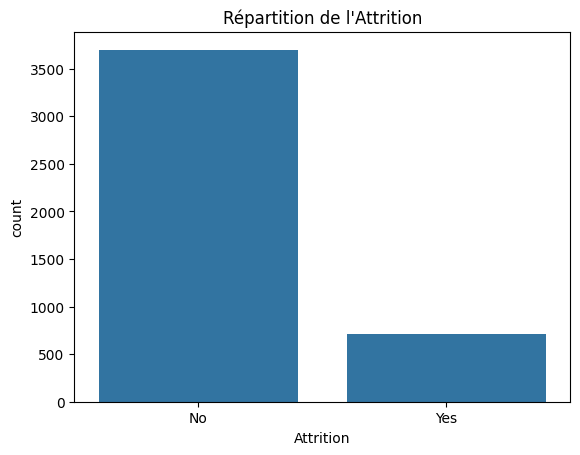

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df_merged, x="Attrition")
plt.title("Répartition de l'Attrition")
plt.show()



### Observation :
La distribution de la variable cible (Attrition) montre un déséquilibre important : 83.9 % des employés ne quittent pas l’entreprise (“No”) contre 16.1 % qui partent (“Yes”). Ce déséquilibre implique que la baseline naïve — prédire "No" pour tout le monde — aurait déjà une précision d’environ 84 %. Tout modèle de Machine Learning devra donc dépasser ce seuil pour être considéré comme performant. Ceci nous renseigne et nourrit l'intuition de ne pas utiliser l'accuracy comme metrique de performance.


## Les Variables Numériques 

Dans cette partie nous allon rechercher les anomalies liés au valeurs numérique

#### l'AGE

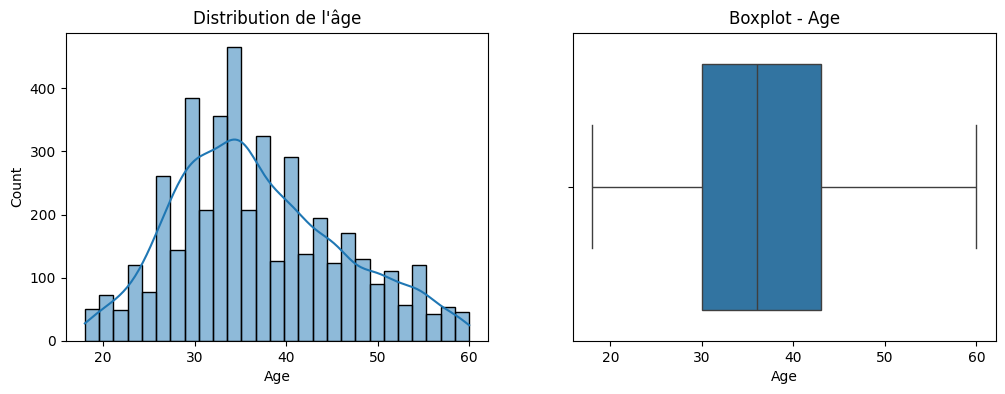

In [87]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(df_merged["Age"], kde=True)
plt.title("Distribution de l'âge")

plt.subplot(1,2,2)
sns.boxplot(x=df_merged["Age"])
plt.title("Boxplot - Age")

plt.show()


La distribution forme une cloche régulière, centrée autour de 35–40 ans.

Les valeurs observées vont d’environ 18 à 60 ans, ce qui correspond à une population active normale.

Le boxplot ne montre aucune valeur extrême anormale (pas d’employés trop jeunes ou trop âgés).

→ Conclusion : aucune anomalie, variable saine.

### MonthlyIncome

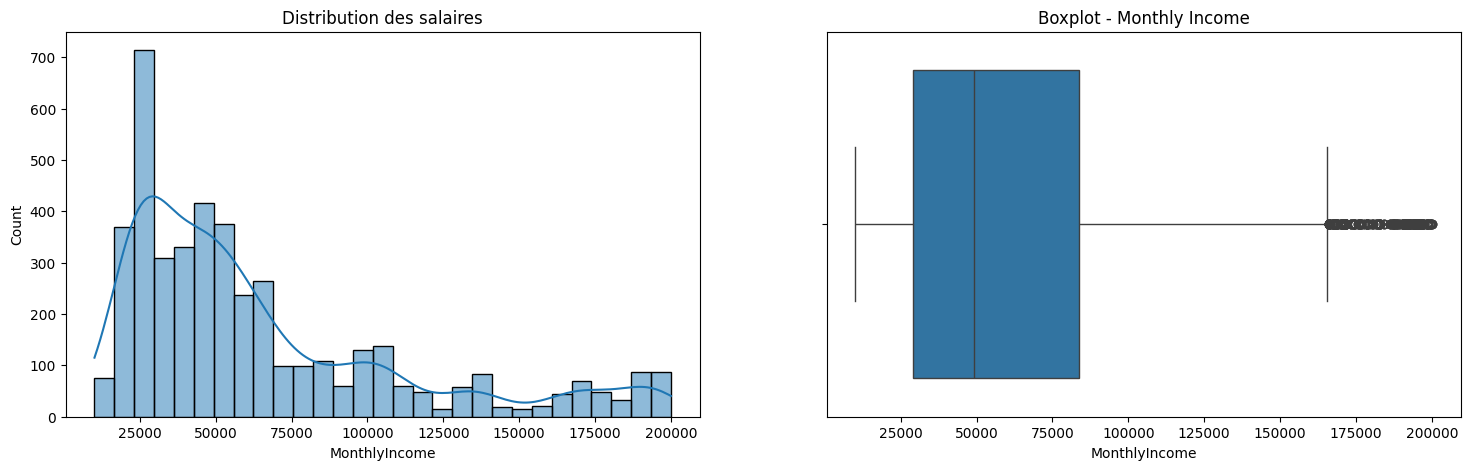

In [44]:
plt.figure(figsize=(18,5))

plt.subplot(1,2,1)
sns.histplot(df_merged["MonthlyIncome"], kde=True)
plt.title("Distribution des salaires")

plt.subplot(1,2,2)
sns.boxplot(x=df_merged["MonthlyIncome"])
plt.title("Boxplot - Monthly Income")

plt.show()


La distribution est très asymétrique, avec beaucoup d’employés à bas/moyen salaire et une traîne à droite correspondant aux postes très rémunérés.

Le boxplot montre de nombreux points extrêmes, mais ceux-ci représentent des postes seniors / direction → ils ne sont pas aberrants.

→ Conclusion : distribution logique pour des données RH. Pas d’anomalie.

### Average work hour

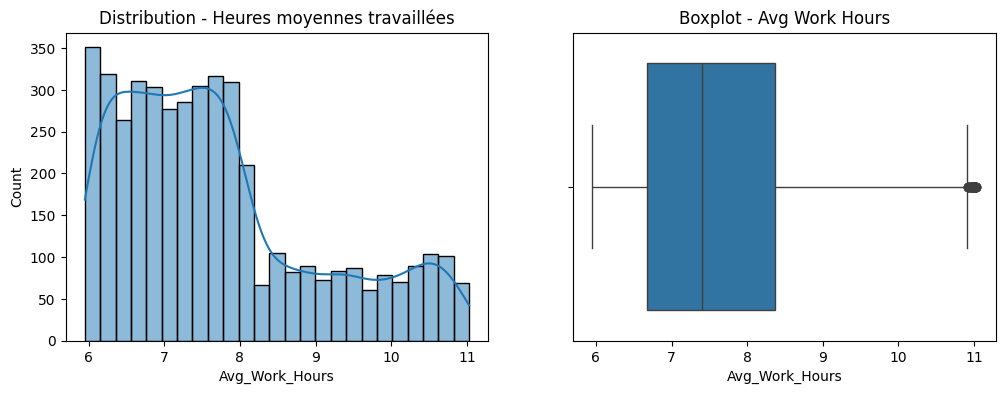

In [45]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(df_merged["Avg_Work_Hours"], kde=True)
plt.title("Distribution - Heures moyennes travaillées")

plt.subplot(1,2,2)
sns.boxplot(x=df_merged["Avg_Work_Hours"])
plt.title("Boxplot - Avg Work Hours")

plt.show()


La distribution est concentrée entre 6 et 9 heures par jour, ce qui correspond à une journée de travail classique.

Un petit groupe atteint 10–11 heures, ce qui peut refléter des employés travaillant plus longtemps, mais rien d’illogique.

Aucun cas extrême (ex : 15–20h, qui indiquerait un bug).

→ Conclusion : la variable est cohérente, aucun problème de badgeuse ou de calcul.

#### Enquête Employés 


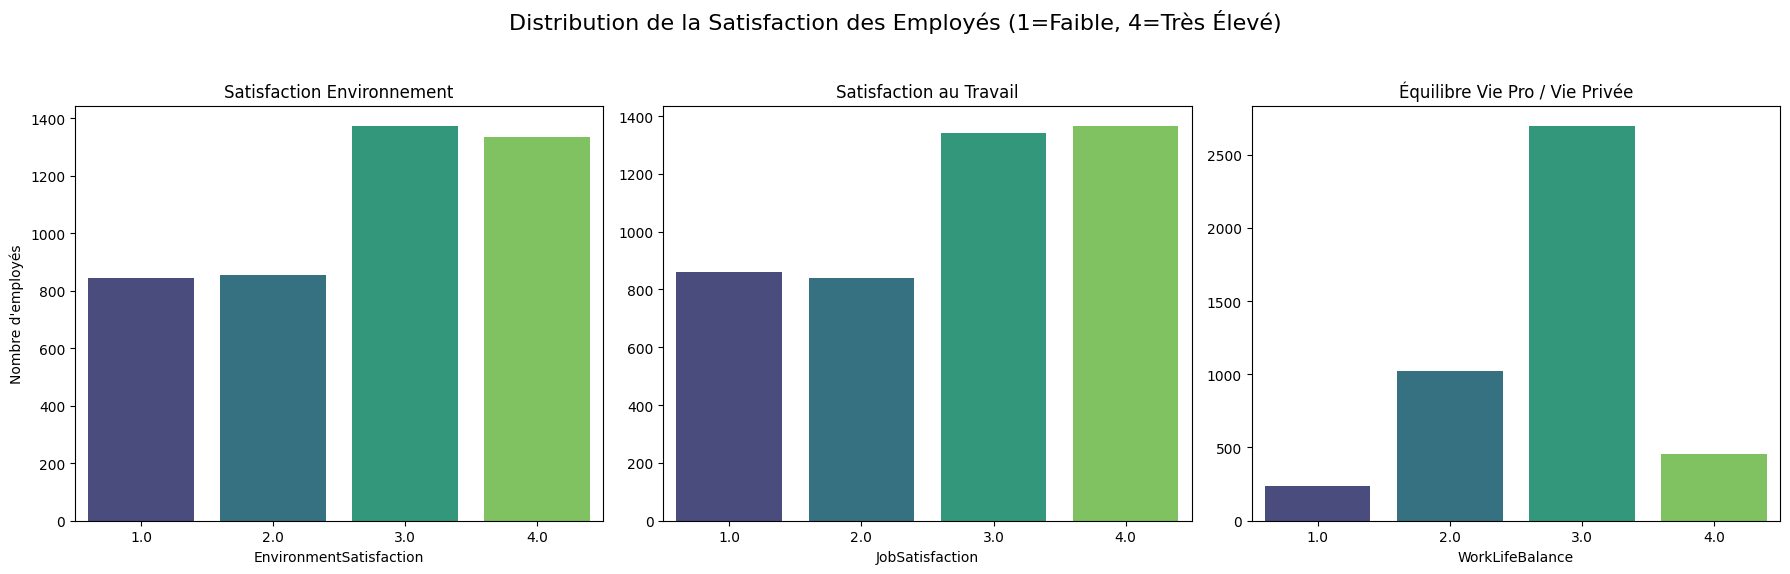

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Distribution de la Satisfaction des Employés (1=Faible, 4=Très Élevé)', fontsize=16)

# Graphique 1 : EnvironmentSatisfaction
sns.countplot(x='EnvironmentSatisfaction', data=df_merged, ax=axes[0], palette='viridis')
axes[0].set_title('Satisfaction Environnement')
axes[0].set_ylabel("Nombre d'employés")

# Graphique 2 : JobSatisfaction
sns.countplot(x='JobSatisfaction', data=df_merged, ax=axes[1], palette='viridis')
axes[1].set_title('Satisfaction au Travail')
axes[1].set_ylabel('')

# Graphique 3 : WorkLifeBalance
sns.countplot(x='WorkLifeBalance', data=df_merged, ax=axes[2], palette='viridis')
axes[2].set_title('Équilibre Vie Pro / Vie Privée')
axes[2].set_ylabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#### Enquête Managers

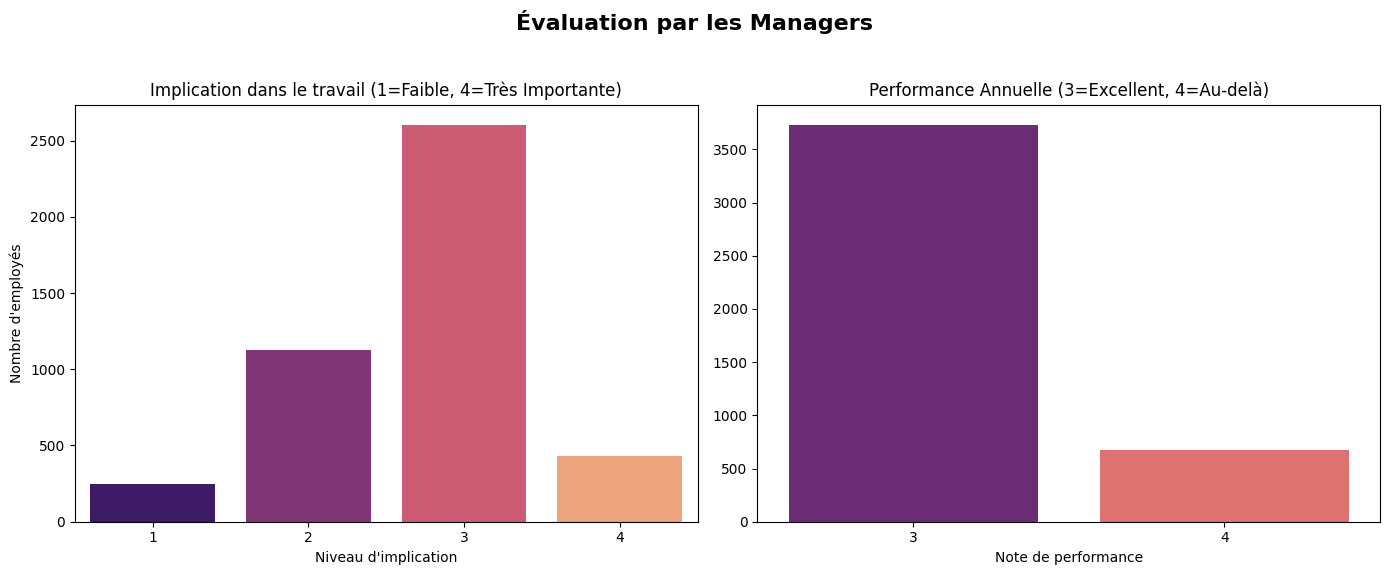

In [92]:
# On utilise directement df_merged (plus de pd.read_csv)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Évaluation par les Managers', fontsize=16, fontweight='bold')

# Graphique 1 : JobInvolvement
sns.countplot(x='JobInvolvement', data=df_merged, ax=axes[0], palette='magma')
axes[0].set_title("Implication dans le travail (1=Faible, 4=Très Importante)")
axes[0].set_ylabel("Nombre d'employés")
axes[0].set_xlabel("Niveau d'implication")

# Graphique 2 : PerformanceRating
sns.countplot(x='PerformanceRating', data=df_merged, ax=axes[1], palette='magma')
axes[1].set_title("Performance Annuelle (3=Excellent, 4=Au-delà)")
axes[1].set_ylabel("") # On enlève le label pour éviter la répétition
axes[1].set_xlabel("Note de performance")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Observations
Nous avons détecteé que la variable PerformanceRating ne contient que des notes 3 (Excellent) et 4 (Au-delà des attentes). Personne n'est noté 1 ou 2. 
On observe que cette variable manque de pouvoir discriminant. Si tout le monde est considéré comme "performant", cette donnée sera probablement inutile pour que l'IA distingue ceux qui partent de ceux qui restent.

Les variables analysées sont JobSatisfaction, EnvironmentSatisfaction, WorkLifeBalance. 
Nous observons que les distributions sont fortement orientées vers les notes positives (3 et 4). Très peu d'employés se déclarent "Insatisfaits" (Note 1). 
Nous pouvons conclure que le taux d'attrition élevé (15%) ne semble pas corrélé à une insatisfaction déclarée massive. Soit les employés ne sont pas honnêtes dans les enquêtes, soit les causes de départ sont ailleurs (salaire, opportunités 
externes)

#### Explorer les heures sup

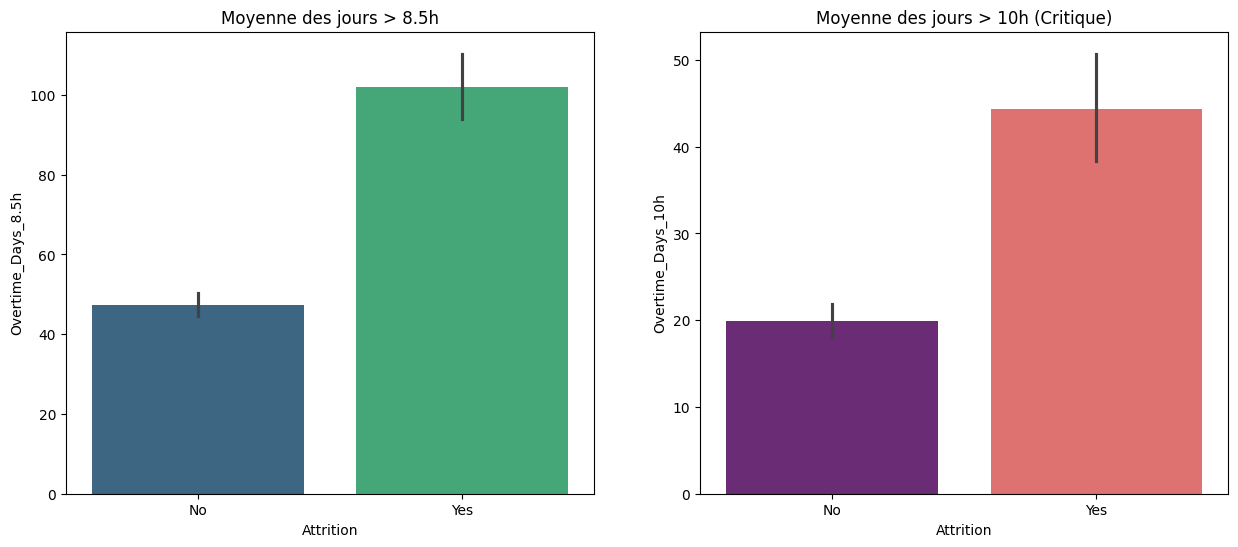

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration simple
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Graphique 1 : Surcharge Modérée (> 8.5h)
sns.barplot(x='Attrition', y='Overtime_Days_8.5h', data=df_merged, ax=axes[0], palette="viridis")
axes[0].set_title("Moyenne des jours > 8.5h")

# Graphique 2 : Surcharge Critique (> 10h)
sns.barplot(x='Attrition', y='Overtime_Days_10h', data=df_merged, ax=axes[1], palette="magma")
axes[1].set_title("Moyenne des jours > 10h (Critique)")

plt.show()

On constate ici que l'attrition est globalement et largement forte chez les employes faisant plus de 8h 30 min d'heure de travail en moyenne par jour. Elle est egalement prononce pour ceux faisant plus de 10h. Ce qui est un indicateur cle de BURNOUT.

## Les Variables catégorielles
On compte le nombre d'employés par JobRole. 

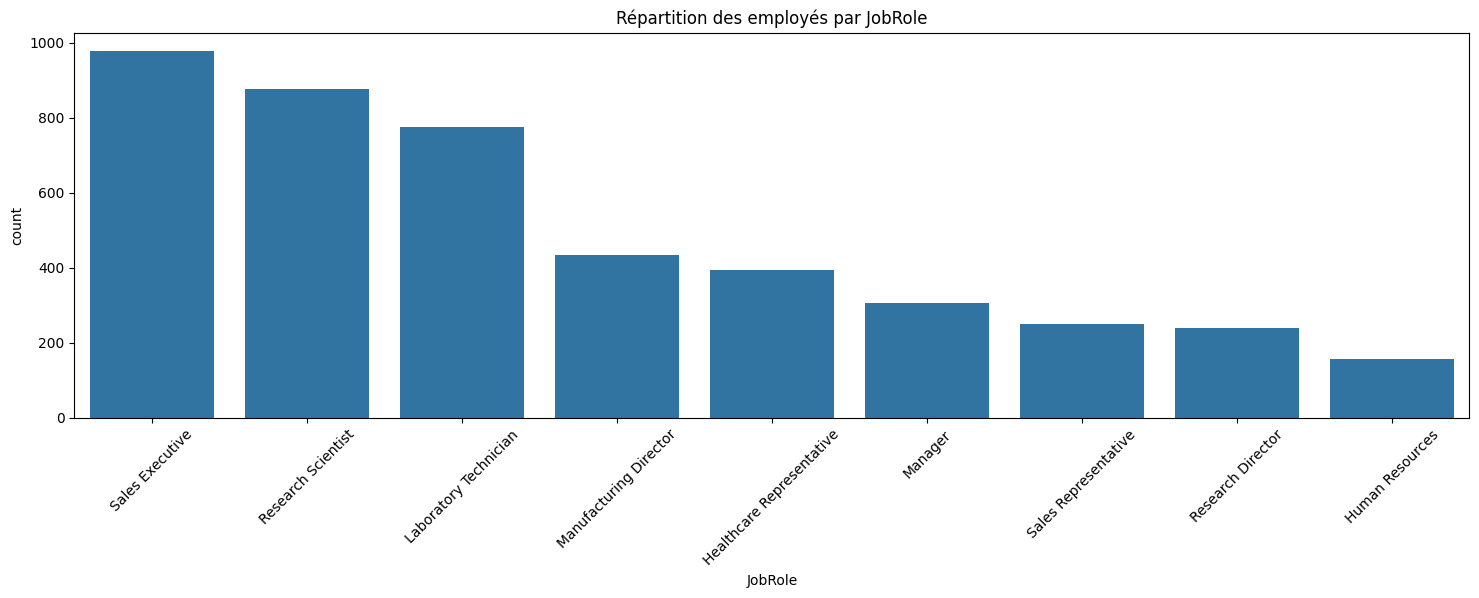

In [48]:
#Répartition des JobRole
plt.figure(figsize=(18,5))
sns.countplot(data=df_merged, x="JobRole", order=df_merged["JobRole"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Répartition des employés par JobRole")
plt.show()



Métiers dominants : Sales Executive, Research Scientist, Lab Technician.

Métiers rares : HR, Director, Manager → analyses moins fiables.

## Étudier les relations (Analyse Bivariée / Multivariée)

### Analyse A : Analyse bivariée — Variables catégorielles vs Attrition

#### JobRole vs Attrition

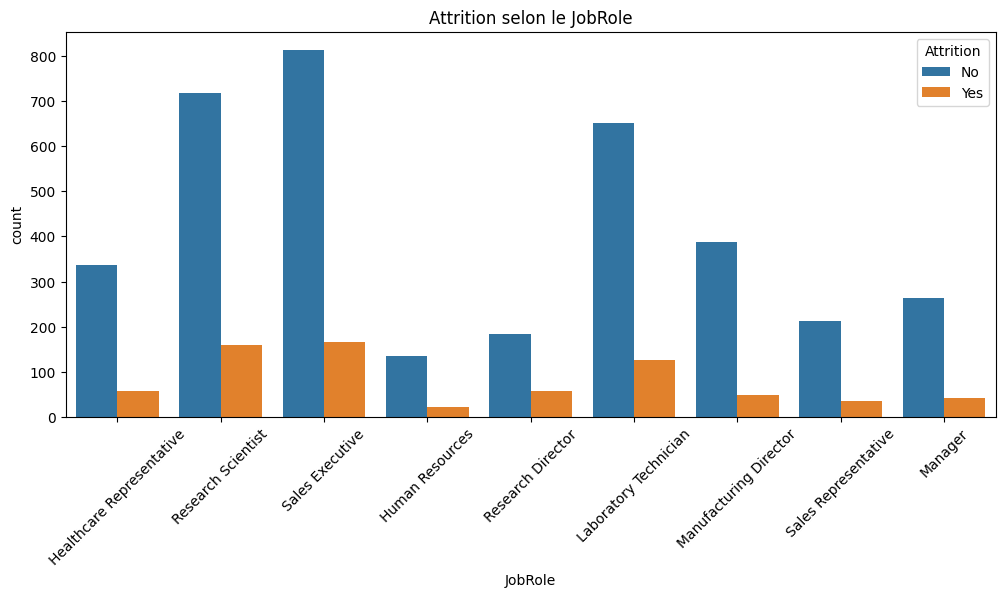

In [49]:
plt.figure(figsize=(12,5))
sns.countplot(data=df_merged, x="JobRole", hue="Attrition")
plt.xticks(rotation=45)
plt.title("Attrition selon le JobRole")
plt.show()


On observe une forte attrition chez les **Sales Executives**, les **Research Scientists** et les **Laboratory Technicians**, très probablement **corrélée** au fait que ces **départements** ont beaucoup plus d'employés.  
D’autant plus vrai que les **nombres** de **départs** les plus bas sont dans les **départements** les moins **fréquentés**.

In [50]:
df_merged.groupby("JobRole")["Attrition"].value_counts(normalize=True)


JobRole                    Attrition
Healthcare Representative  No           0.854962
                           Yes          0.145038
Human Resources            No           0.865385
                           Yes          0.134615
Laboratory Technician      No           0.837838
                           Yes          0.162162
Manager                    No           0.862745
                           Yes          0.137255
Manufacturing Director     No           0.889655
                           Yes          0.110345
Research Director          No           0.762500
                           Yes          0.237500
Research Scientist         No           0.818493
                           Yes          0.181507
Sales Executive            No           0.831288
                           Yes          0.168712
Sales Representative       No           0.855422
                           Yes          0.144578
Name: proportion, dtype: float64

L’attrition n’est pas uniforme selon les métiers : certains rôles (HR, Sales Rep) sont nettement plus instables que les rôles scientifiques ou de direction.

#### BusinessTravel vs Attrition

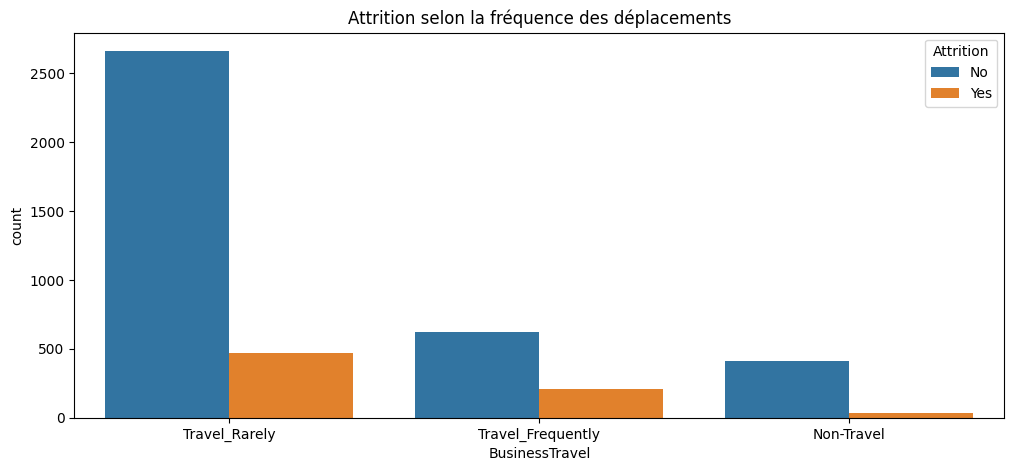

In [51]:
plt.figure(figsize=(12,5))
sns.countplot(data=df_merged, x="BusinessTravel", hue="Attrition")
plt.title("Attrition selon la fréquence des déplacements")
plt.show()


Grosso modo, moins tu voyages, moins tu as des chances de partir. Normal puisque tu ne sauras jamais si l'herbe est plus verte ailleurs. Du coup tu restes.

In [52]:
df_merged.groupby("BusinessTravel")["Attrition"].value_counts(normalize=True)


BusinessTravel     Attrition
Non-Travel         No           0.920000
                   Yes          0.080000
Travel_Frequently  No           0.750903
                   Yes          0.249097
Travel_Rarely      No           0.850431
                   Yes          0.149569
Name: proportion, dtype: float64

Les employés qui voyagent souvent quittent l’entreprise proportionnellement plus que les autres.
Le déplacement semble être un facteur de risque.

#### MaritalStatus vs Attrition

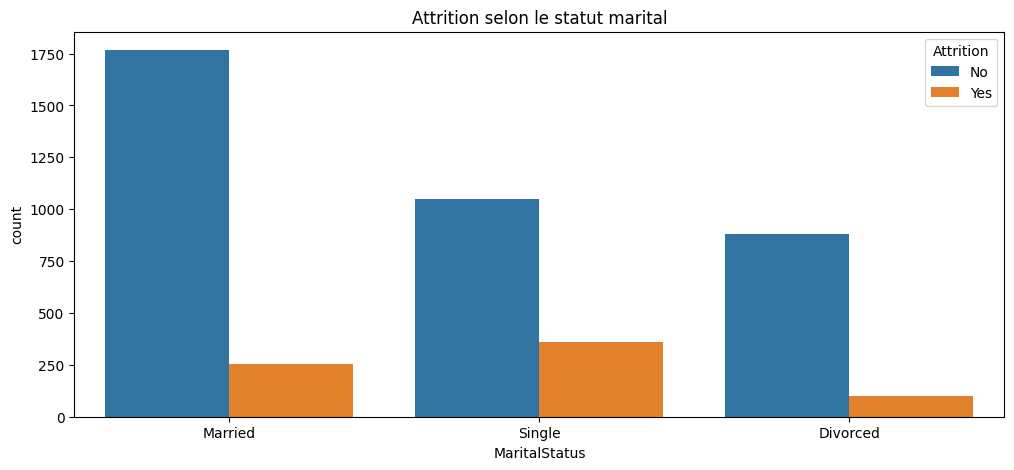

In [53]:
plt.figure(figsize=(12,5))

sns.countplot(data=df_merged, x="MaritalStatus", hue="Attrition")
plt.title("Attrition selon le statut marital")
plt.show()


Globalement, ceux qui ont **expérimenté** le mariage sont plus fidèles à l'entreprise.

In [54]:
df_merged.groupby("MaritalStatus")["Attrition"].value_counts(normalize=True)


MaritalStatus  Attrition
Divorced       No           0.899083
               Yes          0.100917
Married        No           0.875186
               Yes          0.124814
Single         No           0.744681
               Yes          0.255319
Name: proportion, dtype: float64

Le statut marital a un lien clair avec l’attrition : les célibataires sont les plus volatils, les mariés les plus stables.

 #### JobSatisfaction VS Attrition

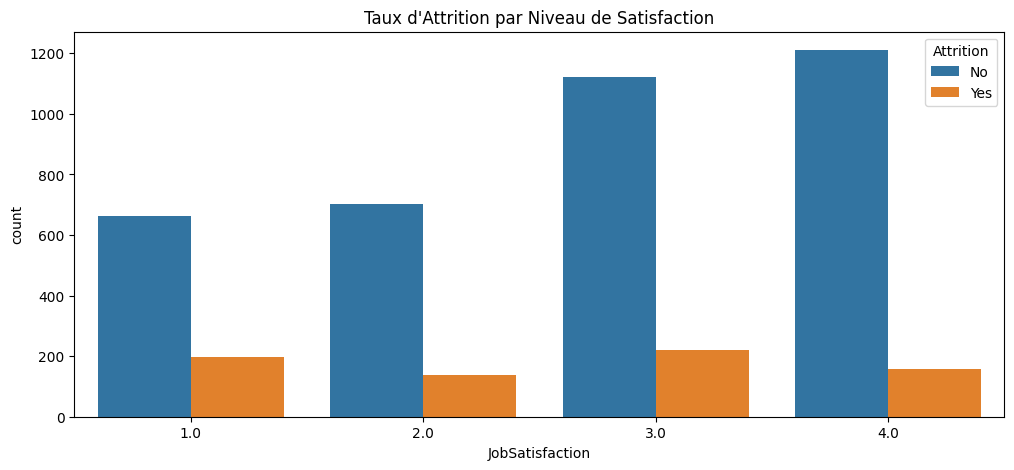

In [55]:
plt.figure(figsize=(12,5))
sns.countplot(data=df_merged, x="JobSatisfaction", hue="Attrition" )
plt.title("Taux d'Attrition par Niveau de Satisfaction")
plt.show()

Certains et une grande partie disent être satisfaits mais s'en vont néanmoins ; on ne saurait se fier à leur jugement **quoiqu'**il y ait une partie insatisfaite qui s'en aille, mais la tendance est à l'**honnêteté**.

 #### WorkLifeBalance VS Attrition

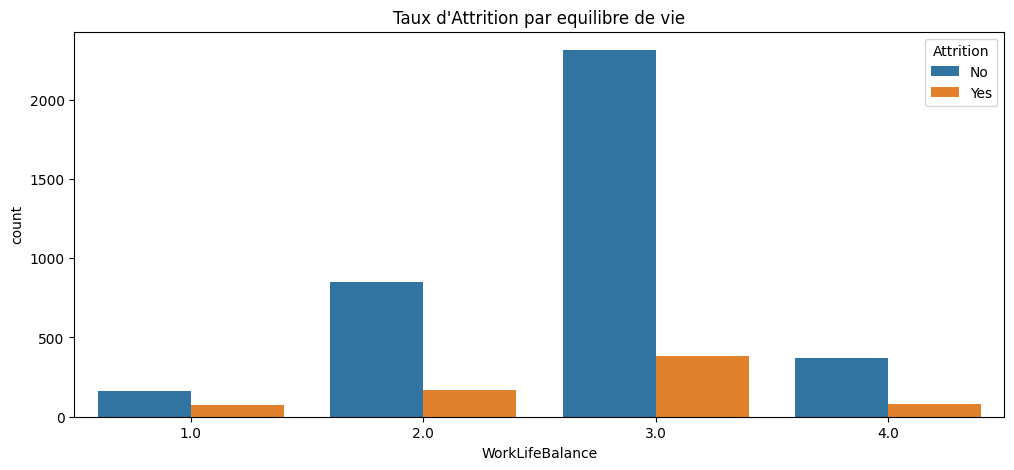

In [106]:

plt.figure(figsize=(12,5))
sns.countplot(data=df_merged, x="WorkLifeBalance", hue="Attrition" )
plt.title("Taux d'Attrition par equilibre de vie")
plt.show()

La **grande** tendance est à l'équilibre de vie, mais la plus grande **quantité** de **départs** se concentre chez ceux qui se disent relativement **stables**.

### Distance from home

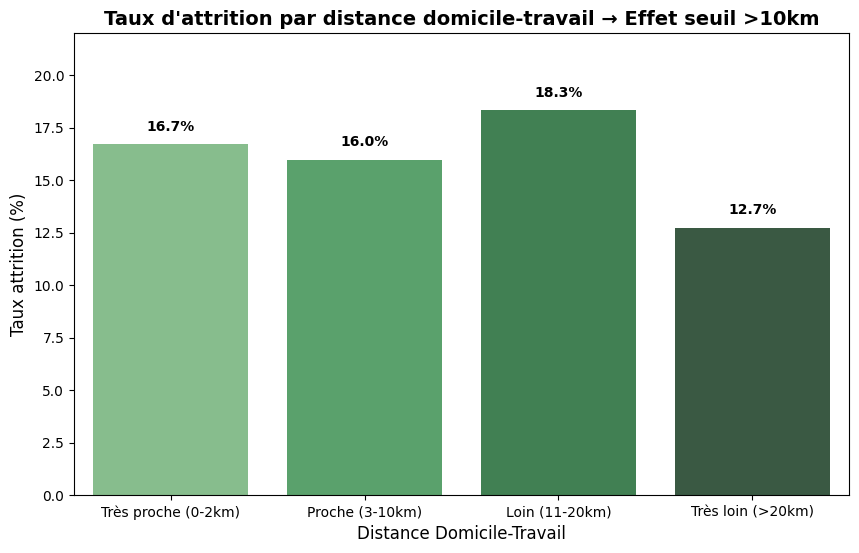

In [57]:

# 1. Création de la variable 'Distance_Bin' (Catégorisation)
# On découpe pour mettre en évidence le seuil des 10km
# 0-2 (Très proche), 3-10 (Proche), 11-20 (Moyen), 20+ (Loin)
bins = [0, 2, 10, 20, 100]
labels = ['Très proche (0-2km)', 'Proche (3-10km)', 'Loin (11-20km)', 'Très loin (>20km)']

df_merged['Distance_Bin'] = pd.cut(df_merged['DistanceFromHome'], bins=bins, labels=labels)

# 2. Conversion Attrition en numérique (0/1)
# Indispensable pour calculer un taux (moyenne)
df_merged['Attrition_Num'] = df_merged['Attrition'].apply(lambda x: 1 if str(x).strip() == 'Yes' else 0)

# 3. Calcul des données pour le graphique
# On groupe par distance et on calcule le pourcentage de départ
attr_dist = df_merged.groupby('Distance_Bin', observed=False)['Attrition_Num'].mean() * 100

# 4. Visualisation
plt.figure(figsize=(10, 6))

# On utilise les données agrégées 'attr_dist'
ax = sns.barplot(
    x=attr_dist.index, 
    y=attr_dist.values, 
    palette='Greens_d'
)

plt.title("Taux d'attrition par distance domicile-travail → Effet seuil >10km", fontweight='bold', fontsize=14)
plt.ylabel("Taux attrition (%)", fontsize=12)
plt.xlabel("Distance Domicile-Travail", fontsize=12)

# Ajout des étiquettes de valeur sur les barres
for i, v in enumerate(attr_dist.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', va='bottom', fontweight='bold')

# Marge au-dessus pour le texte
plt.ylim(0, attr_dist.max() * 1.2)

plt.show()

les plus loins de l'entreprise (>20 km) sont plus fidele a l'entreprise mais ceux qui sont entre 11-20 km le sont beaucoup moins.

### Variables Numériques vs Attrition

#### Avg_Work_Hours vs Attrition

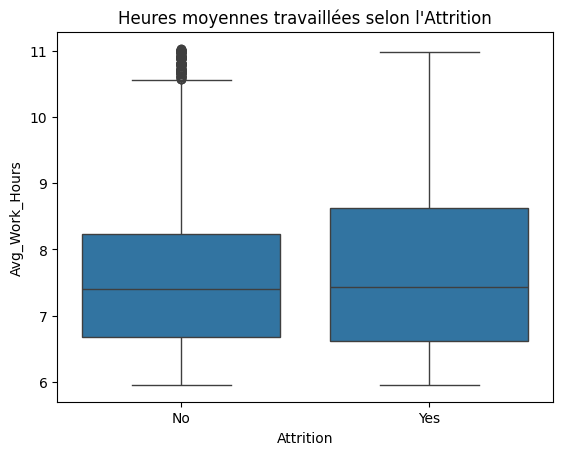

In [58]:
sns.boxplot(x='Attrition', y='Avg_Work_Hours', data=df_merged)
plt.title("Heures moyennes travaillées selon l'Attrition")
plt.show()


Les “No” sont majoritairement autour de 7–8 heures/jour.

Les employés qui quittent travaillent en moyenne plus longtemps.
Cela renforce l’hypothèse d’un lien entre surcharge de travail (burn-out potentiel) et attrition.

#### MonthlyIncome vs Attrition

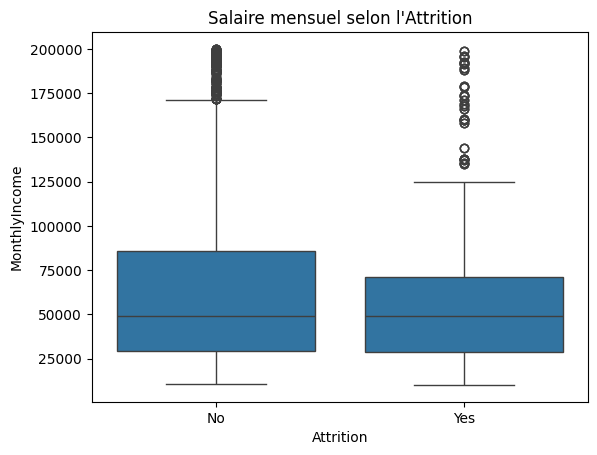

In [59]:
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df_merged)
plt.title("Salaire mensuel selon l'Attrition")
plt.show()


La médiane du salaire des employés qui quittent l’entreprise (Yes) est legerement plus basse que celle des employés qui restent (No).

La dispersion est également plus faible chez les “Yes”, ce qui indique que ceux qui partent appartiennent majoritairement aux catégories salariales inférieures.

Les employés qui quittent l’entreprise sont en moyenne moins bien rémunérés.
Cela suggère que le salaire est un facteur potentiel d’attrition : les employés les moins payés semblent plus susceptibles de partir.

 #### YearsAtCompany VS Attrition

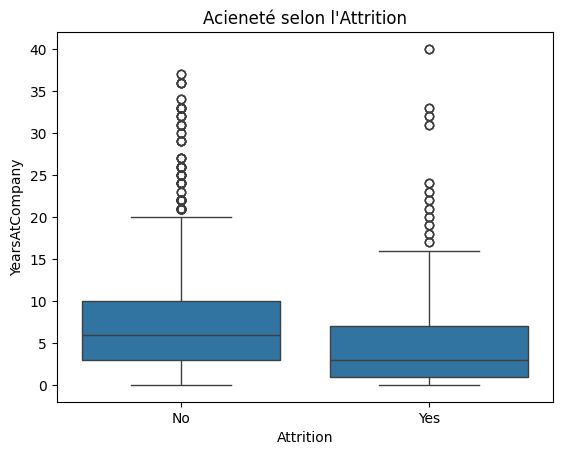

In [60]:
sns.boxplot(x='Attrition', y='YearsAtCompany', data=df_merged)
plt.title("Acieneté selon l'Attrition")
plt.show()

Ceux qui partent partent font globalement moins de temps dans l'entreprise.

#### Age VS Attrition

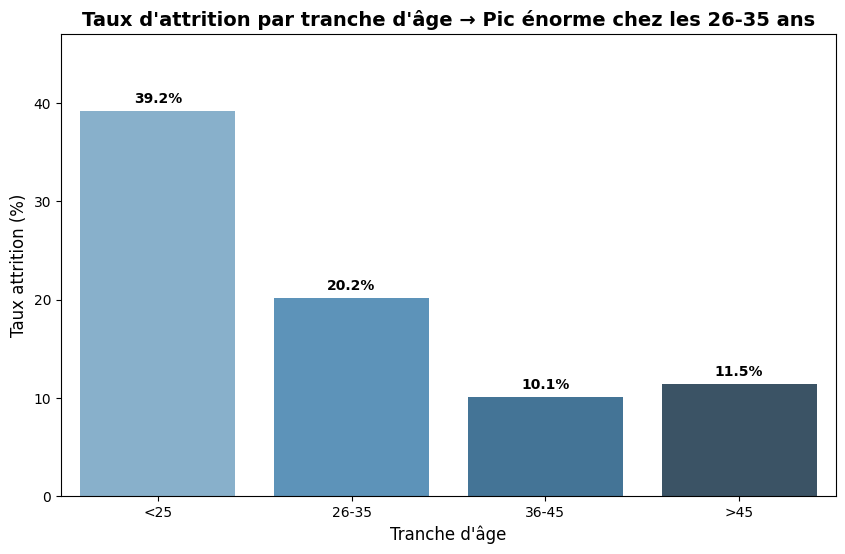

In [61]:
# 1. On s'assure que les groupes d'âge existent (Sécurité)
df_merged['Age_Group'] = pd.cut(
    df_merged['Age'],
    bins=[0, 25, 35, 45, 100],  # 100 comme borne haute sûre (âge max ~60)
    labels=['<25', '26-35', '36-45', '>45'],
    right=False,                # Inclut 25, 35, 45 dans le groupe gauche
    include_lowest=True
)
# 123456

# 2. Conversion Attrition en numérique (0/1) pour le calcul du taux
# C'est l'étape indispensable pour que .mean() fonctionne
df_merged['Attrition_Num'] = df_merged['Attrition'].apply(lambda x: 1 if str(x).strip() == 'Yes' else 0)

# 3. Calcul du taux d'attrition
# On utilise 'Attrition_Num' qui contient des 0 et des 1
attr_age = df_merged.groupby('Age_Group', observed=True)['Attrition_Num'].mean() * 100

# 4. Visualisation (Votre style)
plt.figure(figsize=(10, 6))

# Création du barplot
ax = sns.barplot(x=attr_age.index, y=attr_age.values, palette='Blues_d')

plt.title("Taux d'attrition par tranche d'âge → Pic énorme chez les 26-35 ans", fontweight='bold', fontsize=14)
plt.ylabel("Taux attrition (%)", fontsize=12)
plt.xlabel("Tranche d'âge", fontsize=12)

# Ajout des étiquettes (Pourcentages)
for i, v in enumerate(attr_age.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', va='bottom', fontweight='bold')

# Petit ajustement de l'axe Y pour laisser de la place au texte
plt.ylim(0, attr_age.max() * 1.2)

plt.show()

Par ce graphique, on constate que les jeunes de moins de 35 ans **constituent** plus de la moitié des **départs**, **sûrement** une preuve que l’entreprise a une politique de gestion de ses **jeunes salariés** très peu efficace. **Le** problème ne peut pas **systématiquement** être les jeunes quand même !!!

### Les heures sup

Vérification conversion Attrition :
Attrition
0    3699
1     711
Name: count, dtype: int64
------------------------------
Statistiques par groupe :
                 Taux_Attrition  Effectif
Overtime_Group                           
Q1 (0 jours)           0.102041      2597
Q2 (1-5 jours)         0.123894       339
Q3 (6-20 jours)        0.140221       271
Q4 (20+ jours)         0.304239      1203


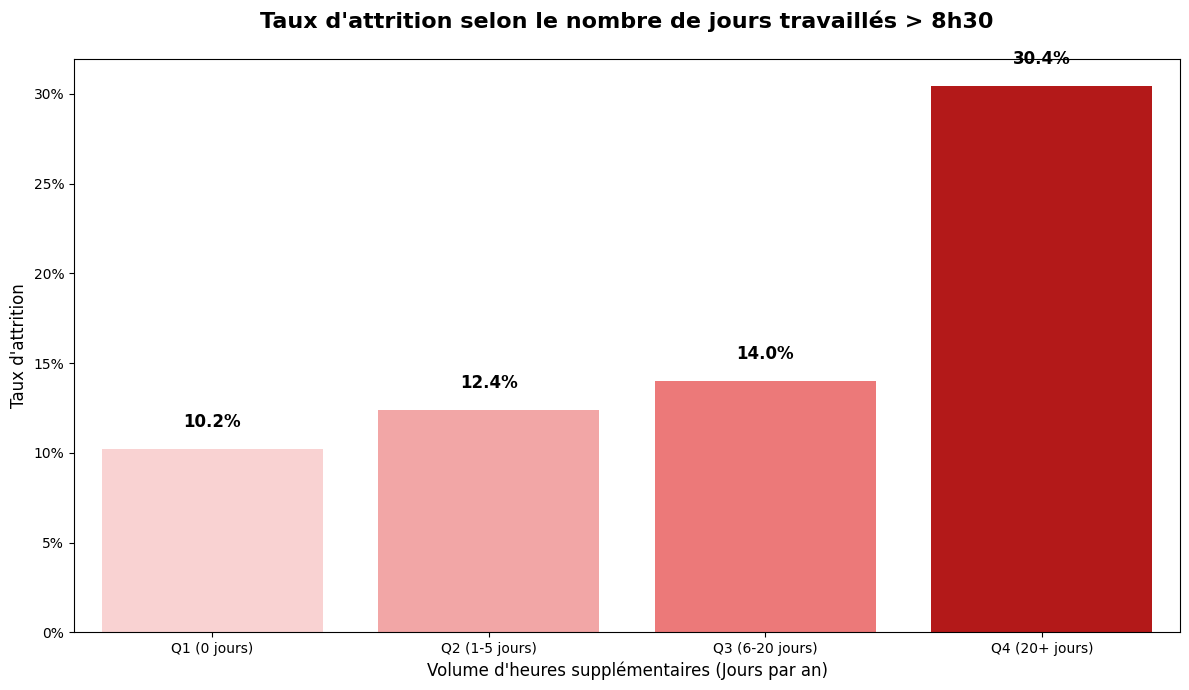

In [62]:

# 1. Préparation sécurisée des données
# On travaille sur une copie pour ne pas abîmer l'original
df_plot = df_merged[['Overtime_Days_8.5h', 'Attrition']].copy()

# -------------------------------------------------------------------------
# CORRECTION CRITIQUE : Conversion forcée et immédiate en numérique
# -------------------------------------------------------------------------
# On s'assure que 'Yes' devient 1 et tout le reste (No) devient 0
df_plot['Attrition'] = df_plot['Attrition'].apply(lambda x: 1 if str(x).strip() == 'Yes' else 0)

# Vérification (Optionnel)
print("Vérification conversion Attrition :")
print(df_plot['Attrition'].value_counts())
print("-" * 30)

# 2. Création des groupes (Binning manuel)
# On découpe en 4 tranches fixes : 0 jour, 1-5 jours, 6-20 jours, >20 jours
bins = [-1, 0, 5, 20, 366]
labels = ['Q1 (0 jours)', 'Q2 (1-5 jours)', 'Q3 (6-20 jours)', 'Q4 (20+ jours)']

df_plot['Overtime_Group'] = pd.cut(
    df_plot['Overtime_Days_8.5h'], 
    bins=bins, 
    labels=labels
)

# 3. Calcul des statistiques
# Maintenant que Attrition est bien des 0 et des 1, 'mean' fonctionnera
stats = df_plot.groupby('Overtime_Group', observed=False)['Attrition'].agg(['mean', 'count'])
stats.columns = ['Taux_Attrition', 'Effectif']

print("Statistiques par groupe :")
print(stats)

# 4. Visualisation
plt.figure(figsize=(12, 7))

# Barplot
ax = sns.barplot(
    x='Overtime_Group', 
    y='Attrition', 
    data=df_plot, 
    palette=['#ffcccc', '#ff9999', '#ff6666', '#cc0000'], # Dégradé rouge
    errorbar=None # Enlève les traits noirs d'incertitude
)

plt.title("Taux d'attrition selon le nombre de jours travaillés > 8h30\n", fontsize=16, fontweight='bold')
plt.ylabel("Taux d'attrition", fontsize=12)
plt.xlabel("Volume d'heures supplémentaires (Jours par an)", fontsize=12)

# Ajout des pourcentages
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width() / 2., height + 0.01, 
                f'{height:.1%}', 
                ha="center", va="bottom", fontsize=12, fontweight='bold')

# Axe Y en pourcentage
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])

plt.tight_layout()
plt.show()

Ici, la tendance est claire : plus **on cumule** d'heures **supplémentaires**, plus l’employé est susceptible de partir. Pour les décideurs, récompenser les efforts pourrait **faire reculer** la barre et limiter les dégâts.

# TOP 30 DES FEATURES


TOP 20 FEATURES PAR POUVOIR PRÉDICTIF (Effect Size) :
                         Feature   Test  Effect_Size       p_value
41                     Age_Group   Chi²     0.207957  4.276839e-41
9                  MaritalStatus   Chi²     0.177211  8.453859e-31
1                 BusinessTravel   Chi²     0.128260  1.764277e-16
21       EnvironmentSatisfaction   Chi²     0.121136  5.780512e-14
22               JobSatisfaction   Chi²     0.108408  3.258771e-11
23               WorkLifeBalance   Chi²     0.106042  9.768883e-11
5                 EducationField   Chi²     0.102348  8.288917e-09
2                     Department   Chi²     0.081218  4.820888e-07
8                        JobRole   Chi²     0.075467  1.485545e-03
15         TrainingTimesLastYear   Chi²     0.071730  9.070058e-04
34  Friday_Evening_Presence_Rate  ANOVA     0.052525  1.184620e-53
28            Overtime_Days_8.5h  ANOVA     0.044207  3.000109e-45
19                JobInvolvement   Chi²     0.042960  4.322253e-02
40     

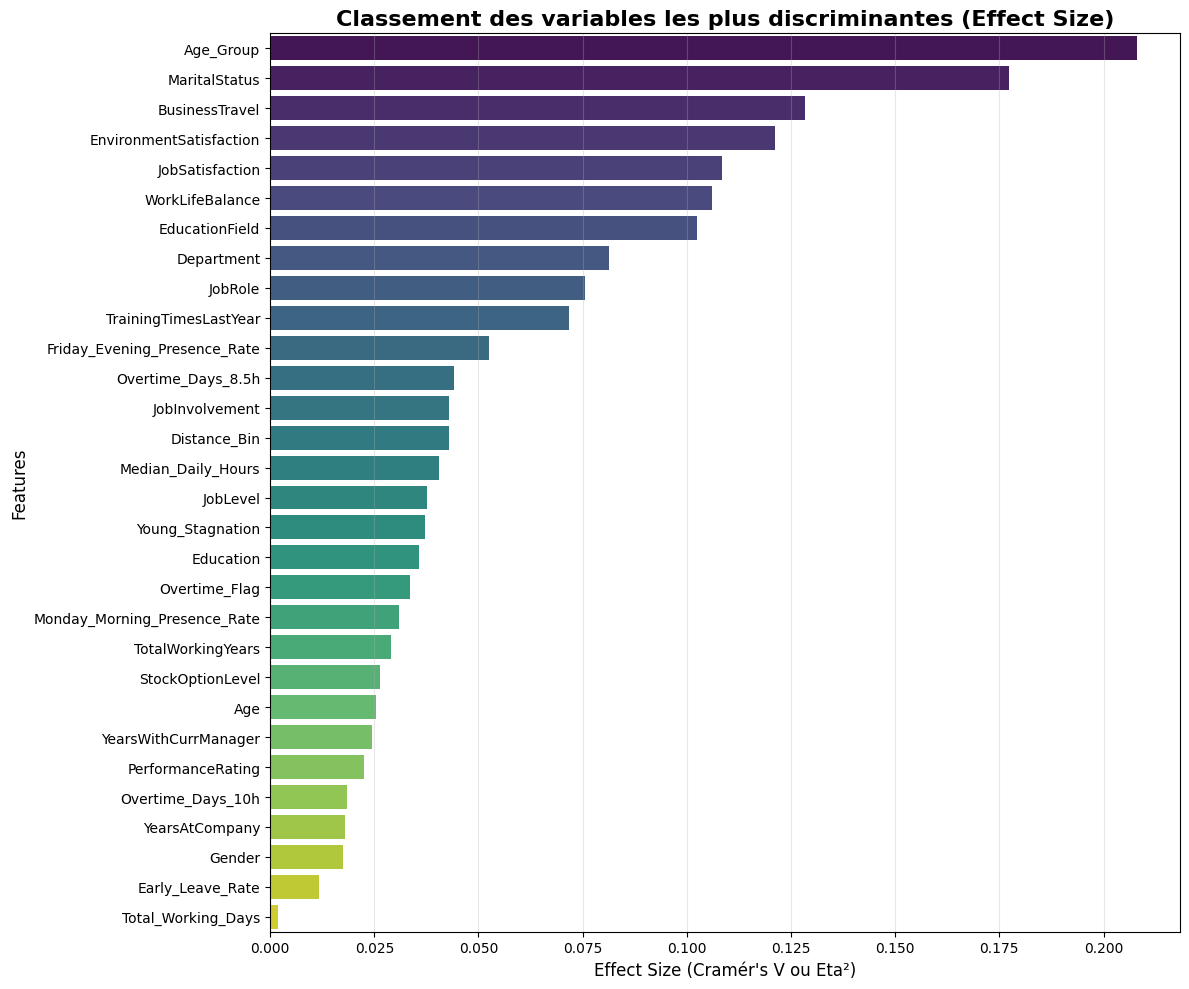

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, f_oneway

# ========================================================
# 2. ANALYSE BIVARIÉE ROBUSTE (ADAPTÉE df_merged)
# ========================================================

def univariate_test_safe(feature, target_col='Attrition'):
    # On travaille sur df_merged (variable globale dans le notebook)
    serie = df_merged[feature]
    
    # 1. Préparation de la cible en numérique (0/1) pour les calculs ANOVA
    # Si la cible est "Yes"/"No", on convertit temporairement
    y_raw = df_merged[target_col]
    if y_raw.dtype == 'object':
        y_num = y_raw.apply(lambda x: 1 if str(x).strip() == 'Yes' else 0)
    else:
        y_num = y_raw

    # Cas colonne constante ou identifiant unique (inutile)
    if serie.nunique() <= 1 or serie.nunique() == len(serie):
        return 'Ignored', 1.0, 0.0
    
    # --- TEST CATÉGORIEL (Chi2 & Cramer's V) ---
    # On considère catégoriel si type 'object', 'category' ou moins de 10 valeurs uniques (ex: notes 1-5)
    if serie.dtype == 'object' or isinstance(serie.dtype, pd.CategoricalDtype) or serie.nunique() < 10:
        # Pour le Chi2, on peut garder la cible en texte ou numérique, peu importe
        contingency = pd.crosstab(serie, y_raw)
        
        if contingency.shape[1] < 2:  # Pas de variation dans la cible pour cette feature
            return 'Chi²', 1.0, 0.0
            
        chi2, p, _, _ = chi2_contingency(contingency)
        
        # Cramér's V
        n = contingency.sum().sum()
        min_dim = min(contingency.shape) - 1
        cramer_v = np.sqrt(chi2 / n / min_dim) if min_dim > 0 else 0.0
        
        return 'Chi²', p, cramer_v
    
    # --- TEST NUMÉRIQUE (ANOVA & Eta-squared) ---
    else:
        # On divise les groupes selon la cible (0 vs 1)
        group_0 = serie[y_num == 0].dropna()
        group_1 = serie[y_num == 1].dropna()
        
        # Si un groupe est vide ou variance nulle
        if len(group_0) == 0 or len(group_1) == 0 or serie.std() == 0:
            return 'ANOVA', 1.0, 0.0
            
        f_stat, p = f_oneway(group_0, group_1)
        
        # Eta-squared (η²) - similaire au R²
        n_total = len(serie.dropna())
        eta_squared = f_stat / (f_stat + n_total - 2) if (f_stat + n_total - 2) > 0 else 0.0
        
        return 'ANOVA', p, eta_squared

# --- APPLICATION SUR TOUTES LES FEATURES ---

results = []
# On exclut la cible elle-même et les identifiants pour ne pas fausser le classement
cols_to_exclude = ['Attrition', 'Attrition_Num', 'EmployeeID', 'StandardHours', 'Over18']

for col in df_merged.columns:
    if col not in cols_to_exclude:
        try:
            test_type, p_value, effect_size = univariate_test_safe(col, target_col='Attrition')
            results.append({
                'Feature': col,
                'Test': test_type,
                'p_value': p_value,
                'Effect_Size': effect_size
            })
        except Exception as e:
            print(f"Erreur sur {col}: {e}")

# Création du DataFrame de résultats
univariate_df = pd.DataFrame(results)

# Nettoyage et tri
univariate_df = univariate_df[univariate_df['Test'] != 'Ignored']
univariate_df = univariate_df.sort_values('Effect_Size', ascending=False)

# Affichage tableau
print("\nTOP 20 FEATURES PAR POUVOIR PRÉDICTIF (Effect Size) :")
print(univariate_df.head(20)[['Feature', 'Test', 'Effect_Size', 'p_value']])

# --- GRAPHIQUE ---
plt.figure(figsize=(12, 10))
# On prend le top 30 pour voir large
top_plot = univariate_df.head(30)

sns.barplot(data=top_plot, y='Feature', x='Effect_Size', palette='viridis')

plt.title("Classement des variables les plus discriminantes (Effect Size)", fontweight='bold', fontsize=16)
plt.xlabel("Effect Size (Cramér's V ou Eta²)", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

 ### Analyse C : La Matrice de Corrélation

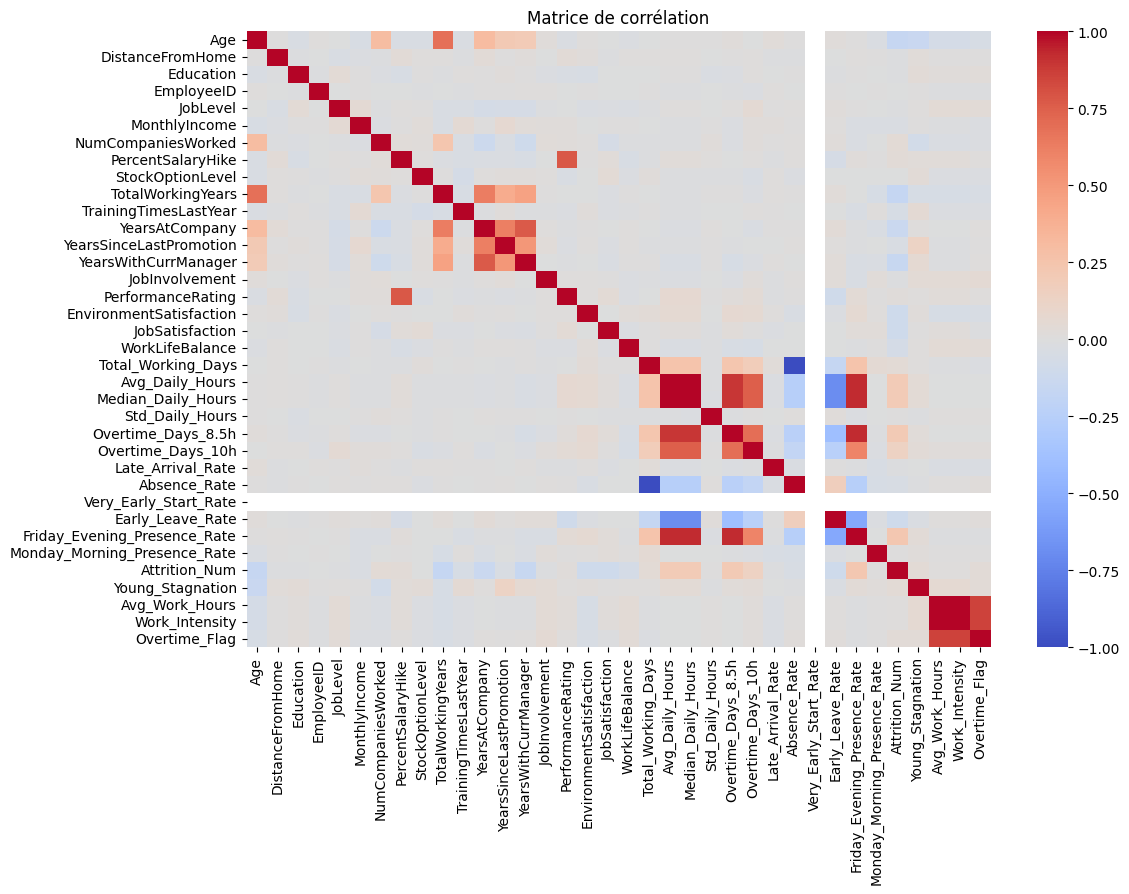

In [64]:
#convertir l'attrition en numérique
df_merged["Attrition_Num"] = df_merged["Attrition"].map({"Yes": 1, "No": 0})

#caclculer la matrice de correlation 
corr = df_merged.corr(numeric_only=True)

#visualiser la heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matrice de corrélation")
plt.show()


# FONCTION POUR DEFINIR LES FEATURES A GARDER POUR LES MODELS

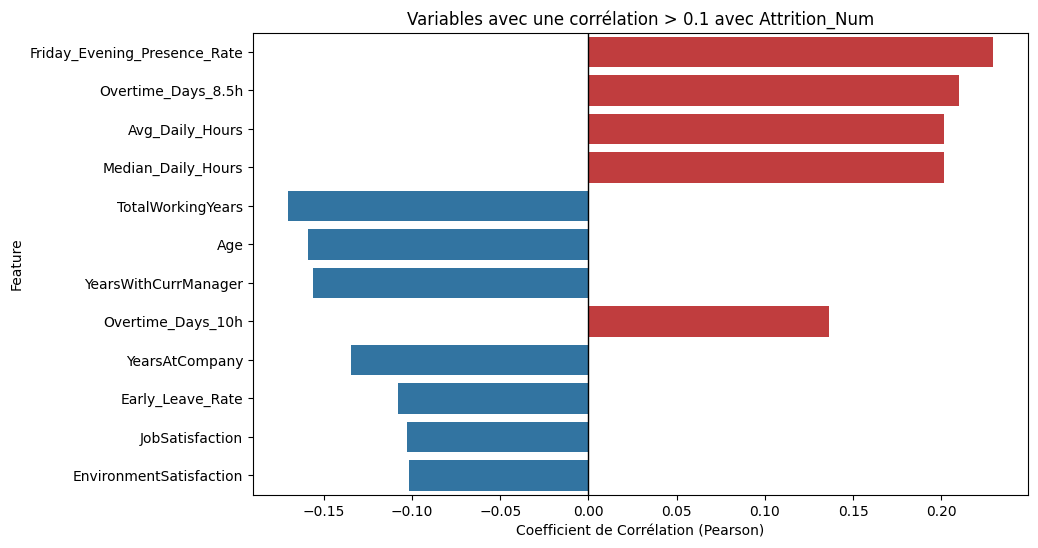

Nombre de variables sélectionnées : 12
Variables retenues : ['Friday_Evening_Presence_Rate', 'Overtime_Days_8.5h', 'Avg_Daily_Hours', 'Median_Daily_Hours', 'TotalWorkingYears', 'Age', 'YearsWithCurrManager', 'Overtime_Days_10h', 'YearsAtCompany', 'Early_Leave_Rate', 'JobSatisfaction', 'EnvironmentSatisfaction']


In [65]:

def selectionner_features_par_correlation(df, target_col='Attrition_Num', threshold=0.1):
    """
    Sélectionne et visualise les variables les plus corrélées avec la cible.
    
    Args:
    - df (pd.DataFrame): Le dataframe contenant les données.
    - target_col (str): Le nom de la colonne cible (ex: 'Attrition_Num').
    - threshold (float): Le seuil minimal de corrélation (valeur absolue) pour garder une variable.
    
    Returns:
    - list: La liste des noms des colonnes sélectionnées.
    """
    # 1. Calcul de la matrice de corrélation (uniquement sur les colonnes numériques)
    corr_matrix = df.corr(numeric_only=True)
    
    # 2. On isole les corrélations avec la cible
    target_corr = corr_matrix[target_col].drop(target_col) # On enlève la cible elle-même
    
    # 3. On trie par valeur absolue de corrélation (les plus fortes en premier)
    # On crée un dataframe temporaire pour faciliter le tri et le filtrage
    features_corr = pd.DataFrame({
        'Feature': target_corr.index,
        'Correlation': target_corr.values,
        'Abs_Correlation': target_corr.abs().values
    })
    
    # On garde seulement celles au-dessus du seuil
    selected_features = features_corr[features_corr['Abs_Correlation'] >= threshold].sort_values(by='Abs_Correlation', ascending=False)
    
    # 4. Visualisation
    plt.figure(figsize=(10, len(selected_features) * 0.5))
    
    # Création d'un code couleur : Rouge pour corrélation positive (augmente l'attrition), Bleu pour négative (réduit l'attrition)
    colors = ['#d62728' if x > 0 else '#1f77b4' for x in selected_features['Correlation']]
    
    sns.barplot(x='Correlation', y='Feature', data=selected_features, palette=colors)
    
    plt.axvline(x=0, color='black', linewidth=1)
    plt.title(f"Variables avec une corrélation > {threshold} avec {target_col}")
    plt.xlabel("Coefficient de Corrélation (Pearson)")
    plt.show()
    
    print(f"Nombre de variables sélectionnées : {len(selected_features)}")
    print("Variables retenues :", selected_features['Feature'].tolist())
    
    return selected_features['Feature'].tolist()

# --- UTILISATION ---
# Assurez-vous d'avoir créé 'Attrition_Num' avant (Yes=1, No=0)
top_features = selectionner_features_par_correlation(df_merged, target_col='Attrition_Num', threshold=0.1)

In [66]:
top_features


['Friday_Evening_Presence_Rate',
 'Overtime_Days_8.5h',
 'Avg_Daily_Hours',
 'Median_Daily_Hours',
 'TotalWorkingYears',
 'Age',
 'YearsWithCurrManager',
 'Overtime_Days_10h',
 'YearsAtCompany',
 'Early_Leave_Rate',
 'JobSatisfaction',
 'EnvironmentSatisfaction']


## 5 Aller vers le Décisionnel RH et la Préparation ML
### Principaux facteurs d'attrition

#### 1. Charge de travail (*Avg_Work_Hours*)
- Insight : Les employés en attrition travaillent en moyenne **+1 à +1.5 h/jour**.
- Action : Alerte RH si la moyenne dépasse **9 h/jour** sur 30 jours.

#### 2. Salaire insuffisant (*MonthlyIncome*)
- Insight : Les départs concernent surtout les **bas salaires**.
- Action : Réajustement salarial ciblé.

#### 3. Faible ancienneté (*YearsAtCompany*)
- Insight : Forte attrition durant les **2 premières années**.
- Action : Onboarding renforcé (mentorat, suivi, intégration).

#### 4. Jeunes employés (*Age*)
- Insight : Les **moins de 30 ans** partent plus souvent.
- Action : Parcours d’évolution accélérée (formation, mobilité interne).

#### 5. Déplacements fréquents (*BusinessTravel*)
- Insight : Les voyageurs fréquents ont un taux d’attrition élevé.
- Action : Réduire les déplacements ou compenser (repos, primes).

#### 6. Métiers en tension (*JobRole*)
- Insight : **Sales Representative** et **Human Resources** sont plus instables.
- Action : Plan de stabilisation (formation, charge, objectifs).


# Action 2 : L’Encodage (Encoding)
Label Encoding pour BusinessTravel (ordre réel).

One-Hot Encoding pour toutes les catégories sans ordre.

Résultat : tableau 100% numérique 

In [68]:
df_merged["BusinessTravel"] = df_merged["BusinessTravel"].map({
    "Non-Travel": 0,
    "Travel_Rarely": 1,
    "Travel_Frequently": 2
})

df_encoded = pd.get_dummies(df_merged, 
                            columns=["JobRole", "Department", "Gender", "MaritalStatus"],
                            drop_first=True)


# Action 3 : La Normalisation (Scaling)
Met les variables autour d’une moyenne 0 et un écart-type 1.

In [69]:
from sklearn.preprocessing import StandardScaler

num_cols = ["Age", "MonthlyIncome", "DistanceFromHome", "TotalWorkingYears",
            "YearsAtCompany", "YearsWithCurrManager", "Avg_Work_Hours"]

scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])


In [70]:
df_merged.head(20)

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeID,Gender,JobLevel,...,Attrition_Num,Young_Stagnation,Avg_Work_Hours,Work_Intensity,Overtime_Flag,Distance_Bin,Age_Group,LongHours,Is_Young,LowIncome
0,51,No,1,Sales,6,2,Life Sciences,1,Female,1,...,0,0,7.406965,0.925871,0,Proche (3-10km),>45,0,0,0
1,31,Yes,2,Research & Development,10,1,Life Sciences,2,Female,1,...,1,0,7.373651,0.921706,0,Proche (3-10km),26-35,0,0,1
2,32,No,2,Research & Development,17,4,Other,3,Male,4,...,0,0,7.718969,0.964871,0,Loin (11-20km),26-35,0,0,0
3,38,No,0,Research & Development,2,5,Life Sciences,4,Male,3,...,0,0,7.013240,0.876655,0,Très proche (0-2km),36-45,0,0,0
4,32,No,1,Research & Development,10,1,Medical,5,Male,1,...,0,0,7.193678,0.899210,0,Proche (3-10km),26-35,0,0,1
5,46,No,1,Research & Development,8,3,Life Sciences,6,Female,4,...,0,0,8.006175,1.000772,0,Proche (3-10km),>45,0,0,1
6,28,Yes,1,Research & Development,11,2,Medical,7,Male,2,...,1,0,10.796096,1.349512,1,Loin (11-20km),26-35,1,1,0
7,29,No,1,Research & Development,18,3,Life Sciences,8,Male,2,...,0,0,6.923570,0.865446,0,Loin (11-20km),26-35,0,1,1
8,31,No,1,Research & Development,1,3,Life Sciences,9,Male,3,...,0,0,6.725621,0.840703,0,Très proche (0-2km),26-35,0,0,1
9,25,No,0,Research & Development,7,4,Medical,10,Female,4,...,0,0,7.236499,0.904562,0,Proche (3-10km),26-35,0,1,0


In [71]:
df_merged.shape

(4410, 48)

In [72]:
df_merged.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome',
       'Education', 'EducationField', 'EmployeeID', 'Gender', 'JobLevel',
       'JobRole', 'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked',
       'PercentSalaryHike', 'StockOptionLevel', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'JobInvolvement', 'PerformanceRating',
       'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance',
       'Total_Working_Days', 'Avg_Daily_Hours', 'Median_Daily_Hours',
       'Std_Daily_Hours', 'Overtime_Days_8.5h', 'Overtime_Days_10h',
       'Late_Arrival_Rate', 'Absence_Rate', 'Very_Early_Start_Rate',
       'Early_Leave_Rate', 'Friday_Evening_Presence_Rate',
       'Monday_Morning_Presence_Rate', 'Attrition_Num', 'Young_Stagnation',
       'Avg_Work_Hours', 'Work_Intensity', 'Overtime_Flag', 'Distance_Bin',
       'Age_Group', 'LongHours', 'Is_Young', 'LowIncome'],
      d

'Friday_Evening_Presence_Rate',
 'Overtime_Days_8.5h',
 'Avg_Daily_Hours',
 'Median_Daily_Hours',
 'TotalWorkingYears',
 'Age',
 'YearsWithCurrManager',
 'Overtime_Days_10h',
 'YearsAtCompany',
 'Early_Leave_Rate',
 'JobSatisfaction',
 'EnvironmentSatisfaction'

In [73]:
df_merged.to_csv("data_final.csv")

In [74]:
selected_features = [
    # Features numériques
    'Friday_Evening_Presence_Rate',   
    'Overtime_Days_8.5h',             
    'Avg_Daily_Hours',                
    'TotalWorkingYears',              
    'YearsWithCurrManager',           
    'Overtime_Days_10h',              
    'YearsAtCompany',                 
    'Early_Leave_Rate',              
    'JobSatisfaction',                
    'EnvironmentSatisfaction',        
    
    # Features catégorielles
    'JobRole',                      
    'Department',                  
    'BusinessTravel',                
    'Age_Group'                     
]

# Target
target = 'Attrition' 

df_model = df_merged[selected_features].copy()
df_model["Attrition"] = df_merged["Attrition"]

df_model.to_csv("df_model.csv")

In [76]:
def prepare_dataset_for_modeling(input_path="df_model.csv", 
                                 output_path="data_ready_for_model.pkl"):
    """
    Prépare le dataset final pour la modélisation.
    - Charge df_model.csv
    - Convertit Attrition en 0/1
    - Encode les catégorielles (Ordinal + OneHot)
    - Standardise les numériques
    - Retourne X (features) et y (target) + sauvegarde pickle
    
    Retour : X (DataFrame prêt), y (Series 0/1)
    """
    # 1. Chargement
    df = pd.read_csv(input_path)
    print(f"Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes")
    
    # 2. Target en binaire
    df['Attrition'] = (df['Attrition'] == 'Yes').astype(int)
    y = df['Attrition']
    df = df.drop('Attrition', axis=1)  # On sépare target
    
    # 3. Séparation numériques / catégorielles
    numeric_cols = [
        'Friday_Evening_Presence_Rate', 'Overtime_Days_8.5h', 'Avg_Daily_Hours',
        'TotalWorkingYears', 'YearsWithCurrManager', 'Overtime_Days_10h',
        'YearsAtCompany', 'Early_Leave_Rate', 'JobSatisfaction', 'EnvironmentSatisfaction'
    ]
    
    ordinal_cols = ['BusinessTravel', 'Age_Group']
    onehot_cols = ['JobRole', 'Department']
    
    # 4. Encodage ordinal (ordre logique)


    age_order = {
    '18-25': 0, 
    '26-35': 1, 
    '36-45': 2, 
    '46-60': 3, 
    '>60': 4
    }

    # df['Age_Group_Encoded'] = df['Age_Group'].map(age_order).fillna(3) 
    df['Age_Group'] = df['Age_Group'].map(age_order).fillna(3) 

    # 5. OneHot pour JobRole et Department
    df = pd.get_dummies(df, columns=onehot_cols, drop_first=True)  # drop_first évite multicolinéarité
    
    # 6. Standardisation des numériques (moyenne 0, écart-type 1)
    df[numeric_cols] = (df[numeric_cols] - df[numeric_cols].mean()) / df[numeric_cols].std()
    df.to_csv("data_model.csv")
    y.to_csv("output.csv")
    
    # 7. Vérification finale
    print(f"Dataset prêt : {df.shape[0]} lignes × {df.shape[1]} features")
    print(f"Features finales : {list(df.columns)}")
    print(f"Répartition target : No={ (y==0).sum() } | Yes={ (y==1).sum() } ({y.mean():.1%} attrition)")
    
    # 8. Sauvegarde pickle (préserve types et encodage)
    ready_data = {'X': df, 'y': y}
    pd.to_pickle(ready_data, output_path)
    print(f"\nSauvegardé → {output_path}")
    print("Contenu : dictionnaire {'X': DataFrame features, 'y': Series target}")

    # df=df.drop(columns=["Unnamed: 0"])
    df = pd.read_csv(input_path, index_col=0)

    
    return df, y

# Utilisation directe
X, y = prepare_dataset_for_modeling("df_model.csv", "data_ready_for_model.pkl") 


Dataset chargé : 4410 lignes × 16 colonnes
Dataset prêt : 4410 lignes × 23 features
Features finales : ['Unnamed: 0', 'Friday_Evening_Presence_Rate', 'Overtime_Days_8.5h', 'Avg_Daily_Hours', 'TotalWorkingYears', 'YearsWithCurrManager', 'Overtime_Days_10h', 'YearsAtCompany', 'Early_Leave_Rate', 'JobSatisfaction', 'EnvironmentSatisfaction', 'BusinessTravel', 'Age_Group', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_Sales Representative', 'Department_Research & Development', 'Department_Sales']
Répartition target : No=3699 | Yes=711 (16.1% attrition)

Sauvegardé → data_ready_for_model.pkl
Contenu : dictionnaire {'X': DataFrame features, 'y': Series target}


In [104]:
X


,Friday_Evening_Presence_Rate,Overtime_Days_8.5h,Avg_Daily_Hours,TotalWorkingYears,YearsWithCurrManager,Overtime_Days_10h,YearsAtCompany,Early_Leave_Rate,JobSatisfaction,EnvironmentSatisfaction,BusinessTravel,Age_Group,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,Department_Research & Development,Department_Sales
0,-0.806542,-0.585157,-0.244095,-1.321929,-1.155804,-0.363226,-0.980903,-0.606504,1.156171,0.252172,1,3.0,False,False,False,False,False,False,False,False,False,True
1,-0.222930,-0.564287,0.013563,-0.678800,-0.034516,-0.363226,-0.327856,-0.663990,-0.663823,0.252172,2,1.0,False,False,False,False,False,True,False,False,True,False
2,-0.806542,-0.585157,-0.513015,-0.807426,-0.314838,-0.363226,-0.327856,-0.319072,-0.663823,-0.665384,2,1.0,False,False,False,False,False,False,True,False,True,False
3,-0.753486,-0.585157,-0.378381,0.221581,0.245806,-0.363226,0.161929,-0.534646,1.156171,1.169728,0,2.0,True,False,False,False,False,False,False,False,True,False
4,0.360682,-0.397333,0.227861,-0.292923,-0.034516,-0.363226,-0.164594,-0.678362,-1.573821,1.169728,1,1.0,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4405,1.209572,0.698305,0.612949,-0.164297,-0.595160,-0.363226,-0.654380,-0.678362,-1.573821,1.169728,1,2.0,False,False,False,False,False,True,False,False,True,False
4406,-0.806542,-0.585157,-1.199684,-0.164297,-0.595160,-0.363226,-0.654380,2.267813,1.156171,1.169728,1,1.0,False,True,False,False,False,False,False,False,True,False
4407,-0.488208,-0.585157,0.004358,-0.807426,-0.595160,-0.363226,-0.491118,-0.678362,0.246174,-1.582940,1,1.0,False,False,False,False,False,False,True,False,True,False
4408,1.634017,1.929594,1.336949,-0.164297,1.086772,-0.119935,0.325191,-0.678362,-1.573821,1.169728,1,2.0,False,True,False,False,False,False,False,False,False,True
